### interpolacija

podatki so v neenakomernih time frames, zato jih interpoliramo na korake 0.05

In [237]:
import numpy as np
import pandas as pd

def interpolate_flight(df, time_col="Time", step=0.05):
    orig_time = df[time_col].astype(float).to_numpy()
    start, end = orig_time.min(), orig_time.max()
    
    new_time = np.arange(start, end, step)  #ustvarimo nov čas
    
    interp_data = {"Time": new_time}
    #izbrani = df.drop("Position", axis=1)
    for col in df.columns:
        if col != time_col and np.issubdtype(df[col].dtype, np.number):
            interp_data[col] = np.interp(new_time, orig_time, df[col])
    
    return pd.DataFrame(interp_data)


In [207]:
df["Position"]

1        0.0
2        1.0
3        2.0
4        3.0
5        4.0
       ...  
220    219.0
221    220.0
222    221.0
223    222.0
224    223.0
Name: Position, Length: 224, dtype: float64

In [178]:
df.drop("Position", axis=1)

,Height above ground [m],Time,X [m],Y [m],Z [m],Opening Angle [°],Stalling Angle Left [°],Stalling Angle Right [°],Roll Angle Left [°],Roll Angle Right [°],...,W11_Speed,W11_Tangent,W11_Turbulence,W11_CleanTan,W11_Cross,W12_Speed,W12_Tangent,W12_Turbulence,W12_CleanTan,W12_Cross
0,NaN,0.071,-81.79,0.00,43.40,NaN,NaN,NaN,NaN,NaN,...,0.7,-0.68,0.09,-0.68,0.17,0.9,-0.85,0.05,-0.85,0.34
1,2.93,4.161,0.03,0.00,-0.01,0.0,-11.500,-11.500,0.000,0.000,...,0.8,-0.77,0.12,-0.77,0.22,1.0,-0.96,0.04,-0.96,0.25
2,2.88,4.303,1.34,0.01,-0.21,2.9,-8.516,-9.408,-1.814,10.681,...,0.8,-0.77,0.12,-0.77,0.22,1.0,-0.96,0.04,-0.96,0.25
3,2.88,4.289,2.38,-0.00,-0.34,4.9,-4.662,-6.752,-0.143,11.165,...,0.8,-0.77,0.12,-0.77,0.22,1.0,-0.96,0.04,-0.96,0.25
4,2.92,4.404,3.42,-0.00,-0.47,7.7,-0.862,-4.479,0.062,5.115,...,0.8,-0.77,0.12,-0.77,0.22,1.0,-0.95,0.02,-0.95,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,0.33,10.852,174.97,-5.41,-104.49,15.7,-12.997,-19.091,-8.786,3.038,...,0.8,-0.65,0.03,-0.65,0.43,1.1,-1.08,0.10,-1.08,0.14
206,0.19,10.880,175.75,-5.52,-105.13,15.0,-13.956,-21.251,-9.271,3.231,...,0.8,-0.65,0.03,-0.65,0.43,1.1,-1.08,0.10,-1.08,0.14
207,0.10,10.909,176.52,-5.62,-105.78,14.3,-14.915,-23.413,-9.756,3.424,...,0.8,-0.65,0.03,-0.65,0.43,1.1,-1.08,0.10,-1.08,0.14
208,0.03,10.936,177.22,-5.55,-106.29,10.5,-15.587,-25.487,-9.852,3.609,...,0.8,-0.65,0.03,-0.65,0.43,1.1,-1.08,0.10,-1.08,0.14


In [267]:
import os

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned'
new_folder = os.path.join(folder_path, "normalized")

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df[1:]

        # primer
        interp_df = interpolate_flight(df, time_col="Time", step=0.05)
        #print(interp_df.head())
        cleaned_filename = os.path.splitext(filename)[0] + "_normalized.csv"
        cleaned_path = os.path.join(new_folder, cleaned_filename)
        interp_df.to_csv(cleaned_path, index=False)

In [239]:
print(f"Processing file: {filename}")
print(df.columns)

Processing file: normalized.zip
Index(['Position', 'Height above ground [m]', 'Time', 'X [m]', 'Y [m]',
       'Z [m]', 'Opening Angle [°]', 'Stalling Angle Left [°]',
       'Stalling Angle Right [°]', 'Roll Angle Left [°]',
       'Roll Angle Right [°]', 'Yaw Angle Left [°]', 'Yaw Angle Right [°]',
       'Speed hor. [km/h]', 'Speed vert. [km/h]', 'Speed resulting [km/h]',
       'W1_Speed', 'W1_Tangent', 'W1_Turbulence', 'W1_CleanTan', 'W1_Cross',
       'W2_Speed', 'W2_Tangent', 'W2_Turbulence', 'W2_CleanTan', 'W2_Cross',
       'W3_Speed', 'W3_Tangent', 'W3_Turbulence', 'W3_CleanTan', 'W3_Cross',
       'W4_Speed', 'W4_Tangent', 'W4_Turbulence', 'W4_CleanTan', 'W4_Cross',
       'W5_Speed', 'W5_Tangent', 'W5_Turbulence', 'W5_CleanTan', 'W5_Cross',
       'W6_Speed', 'W6_Tangent', 'W6_Turbulence', 'W6_CleanTan', 'W6_Cross',
       'W7_Speed', 'W7_Tangent', 'W7_Turbulence', 'W7_CleanTan', 'W7_Cross',
       'W8_Speed', 'W8_Tangent', 'W8_Turbulence', 'W8_CleanTan', 'W8_Cross',
      

In [218]:
zones = {
    "takeoff": ["W1", "W2", "W3"],
    "mid":     ["W4", "W5", "W6", "W7"],
    "landing": ["W8", "W9", "W10", "W11", "W12"]
}

wind_features = ["Tangent", "Cross", "Turbulence"]

### preprocessing

In [268]:


def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    vx = np.gradient(x, dt)   #gradient za hitrost
    vy = np.gradient(y, dt)
    vz = np.gradient(z, dt)


    states = np.stack([x, y, z, vx, vy, vz], axis=1)   #zgradimo state vector X
    

    roll = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    speed = np.sqrt(vx**2 + vy**2 + vz**2)
    
    observations = np.stack([x, y, z, roll, yaw, speed], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 9)
    
    return states, observations, controls


#### preverjanje

In [22]:
#filename = "999_999_Jumper_Anon_ANO_1_20240409-103924_C_OfficialResults_cleaned_normalized.csv"
#df = pd.read_csv(os.path.join(folder_path, filename))
#X, Y, U = preprocess_flight_normalized(df, step=0.05)

določiš katere spremenljivke bodo imele katero vlogo v ssm

In [353]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned\normalized'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 6), Y:(135, 6), U:(135, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 6), Y:(131, 6), U:(131, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 6), Y:(145, 6), U:(145, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 6), Y:(139, 6), U:(139, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_normalized.csv -> X:(136, 6), Y:(136, 6), U:(136, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 6), Y:(132, 6), U:(132, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 6), Y:(156, 6), U:(156, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults_cleaned_norma

In [354]:
from sklearn.model_selection import train_test_split
import numpy as np

# Train/test split along time dimension
X_train, X_test, Y_train, Y_test, U_train, U_test = train_test_split(
    X_list, Y_list, U_list, test_size=0.2, random_state=42
)


spraviš v pravo obliko, zaradi lažjega računanja jih spraviš v enotne vektorje

In [355]:
import numpy as np

# Prepare stacked data for system identification
X_t = np.vstack([seq[:-1] for seq in X_train])      # state at time t   
X_next = np.vstack([seq[1:] for seq in X_train])    # state at time t+1  #spustimo 0. da zamaknemo
U_t = np.vstack([u[:-1] for u in U_train])          # control at time t  - matchamo s X_t
Y_t = np.vstack([obs[:-1] for obs in Y_train])      # observation at time t

print(f"X_t: {X_t.shape}, X_next: {X_next.shape}, U_t: {U_t.shape}, Y_t: {Y_t.shape}")


X_t: (22338, 6), X_next: (22338, 6), U_t: (22338, 9), Y_t: (22338, 6)


s pomočjo MNK (metode najmanjšega kvadrata) določimo phi matriko, iz katere ven dobimo A in B matriko

In [356]:
# Build regression matrix
Phi = np.hstack([X_t, U_t])   # [x_t | u_t]...skupaj sestavimo v eno matriko


Theta, _, _, _ = np.linalg.lstsq(Phi, X_next, rcond=None)  #rešitev po MNK (stabilna verzija)
    #output MNK: matrika A in B, reziduali, rank (A in B), singularnosti (vse razen 1. ignoriramo)
    #ponovimo mnk za vektor, za vsako vrstico v output matriki...MNK za matrike

# Extract A and B
state_dim = X_t.shape[1]
control_dim = U_t.shape[1]
A = Theta[:state_dim, :].T   #prvih state_dim vrstic, vsi stolpci
B = Theta[state_dim:, :].T   #the rest (control_dim)

print("A shape:", A.shape)
print("B shape:", B.shape)


A shape: (6, 6)
B shape: (6, 9)


ponovimo isto, samo da se po liniji vplivov premaknemo dol iz x na y, da lahko dobimo še C in D matriki

In [357]:
Phi_y = np.hstack([X_t, U_t])
Theta_y, _, _, _ = np.linalg.lstsq(Phi_y, Y_t, rcond=None)

obs_dim = Y_t.shape[1]
C = Theta_y[:state_dim, :].T
D = Theta_y[state_dim:, :].T

print("C shape:", C.shape)
print("D shape:", D.shape)


C shape: (6, 6)
D shape: (6, 9)


izračunamo dejansko simulacijo

In [279]:
def simulate_trajectory(x0, U_seq, A, B):
    """
    Simulate trajectory using learned A, B.
    x0: initial state (shape: [state_dim])
    U_seq: control inputs (shape: [T, control_dim])
    """
    X_sim = [x0]  #shrani initial state
    for u in U_seq:                     # @...matrix multiplication
        x_next = A @ X_sim[-1] + B @ u  #Zračuna naslednji korak
        X_sim.append(x_next)            #shrani
    return np.array(X_sim)

# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_train[4][0]      # first sublist first element
U_seq = U_train[4]      # controls for that flight
X_sim = simulate_trajectory(x0, U_seq, A, B)

print("Simulated trajectory shape:", X_sim.shape)


Simulated trajectory shape: (129, 6)


#### eigenvalues / stability za A

2/6 lastnih vrednosti sta po abs. večji od ena, kar lahko pripelje do nestabilnosti. 

In [358]:
import numpy as np
from scipy.linalg import schur, rsf2csf, ordqz

def project_A_schur(A, target=0.98):
    # Real Schur: A = Q R Q^T, R is quasi-upper-triangular with 1x1 (real) and 2x2 (complex pairs)
    R, Q = schur(A, output='real')
    n = R.shape[0]
    i = 0
    while i < n:
        if i < n-1 and abs(R[i+1, i]) > 1e-12:
            # 2x2 block (complex conjugate pair)
            block = R[i:i+2, i:i+2]
            eigs = np.linalg.eigvals(block)
            maxmag = np.max(np.abs(eigs))
            if maxmag > target:
                scale = target / maxmag
                R[i:i+2, i:i+2] *= scale
            i += 2
        else:
            # 1x1 block
            val = R[i, i]
            mag = abs(val)
            if mag > target and mag > 0:
                R[i, i] = val * (target / mag)
            i += 1
    A_proj = Q @ R @ Q.T
    return A_proj

# usage
A_stable = project_A_schur(A, target=0.98)


Po MNK prilagodimo tudi B matriko in sicer x_t+1 ≈ A_stable * x_t + B * u_t + b

In [363]:
M = X_next - X_t @ A_stable.T
U_new = np.hstack([U_t, np.ones((U_t.shape[0],1))])

#rešimo sistem U_new * W ≈ M  kjer je W...(m+1, n)
W, *_ = np.linalg.lstsq(U_new, M, rcond=None)

B_new = W[:-1, :].T
b_new = W[-1, :]

In [366]:
def simulate(A, B, b, x0, U_seq):
    X = [x0]
    for u in U_seq:
        X.append(A @ X[-1] + B @ u + b)
    return np.array(X)

In [370]:
# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_train[1][0]      # first sublist first element
U_seq = U_train[1]      # controls for that flight
X_sim = simulate(A_stable, B_new, b_new, x0, U_seq)

print("Simulated trajectory shape:", X_sim.shape)

Simulated trajectory shape: (132, 6)


##### shranjevanje to share

In [193]:
step = 0.05
num_steps = X_state.shape[0]
time_vector = np.arange(num_steps) * step

In [29]:
import numpy as np

# Example matrices
np.savez("ssm_data.npz", 
         A=A, 
         B=B, 
         C=C, 
         D=D, 
         X_sim=X_sim, 
         U=U_seq, 
         time=time_vector)


### plotting

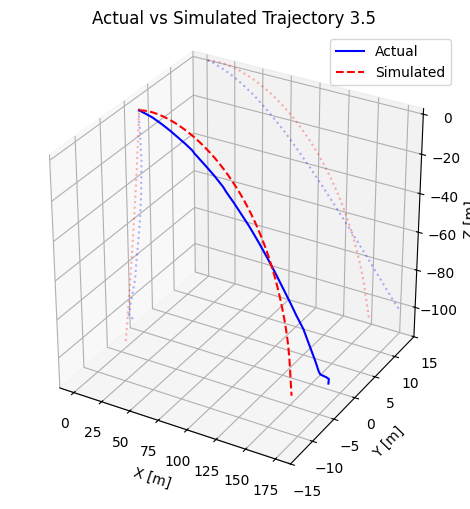

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


    #(spreminjaš 1. [] v 1. vrstici)
actual = X_test[1][:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
sim = X_sim[:, :3]          # same iz simulacije

Xa = actual[:,0]
Ya = actual[:,1]
Za = actual[:,2]

Xs = sim[:,0]
Ys = sim[:,1]
Zs = sim[:,2]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


# Ground projections
ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')



ax.set_title("Actual vs Simulated Trajectory ")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.legend()
ax.set_box_aspect([1,1,1])
ax.set_ylim(-15, 15)

plt.legend()
plt.tight_layout()
plt.show()


#### loop

In [373]:
range(len(X_test))

range(0, 42)

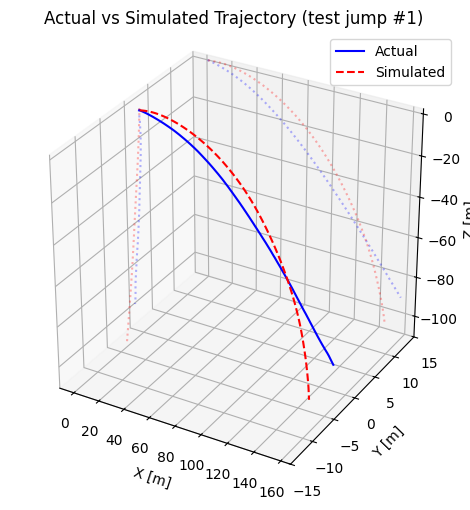

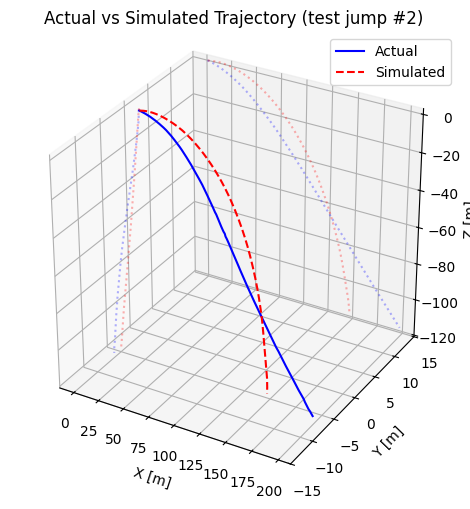

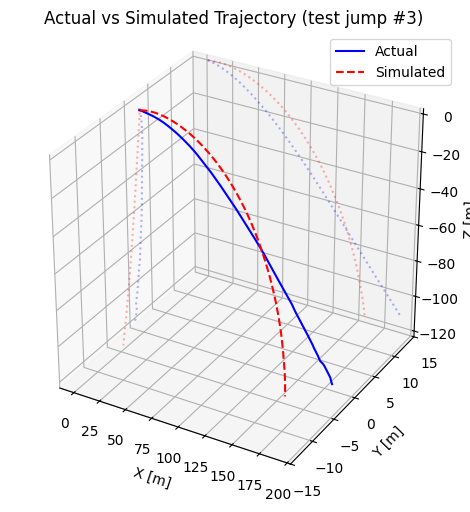

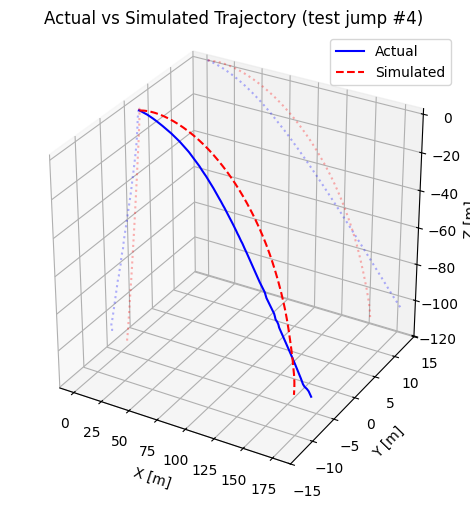

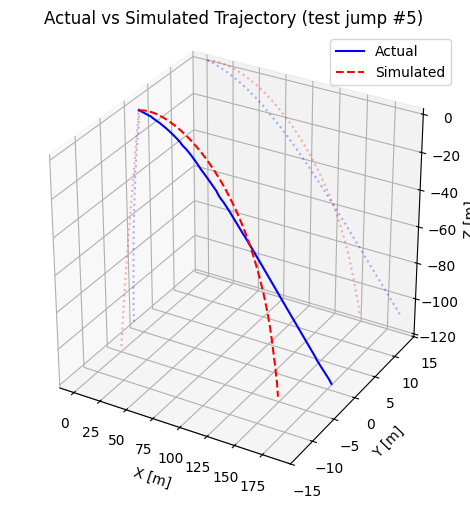

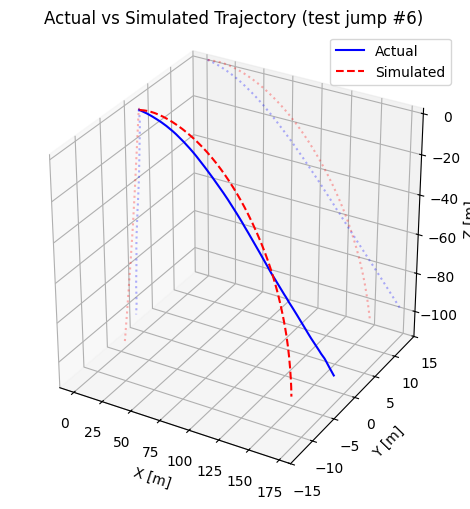

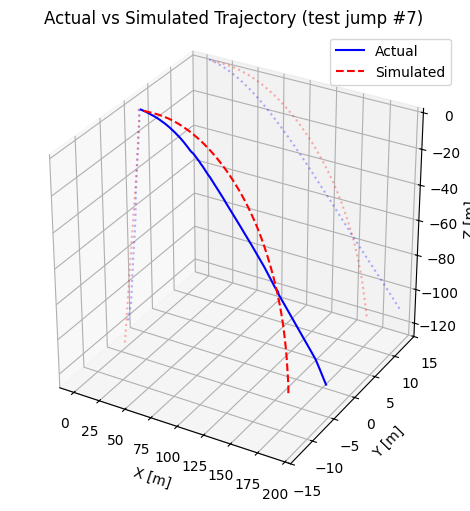

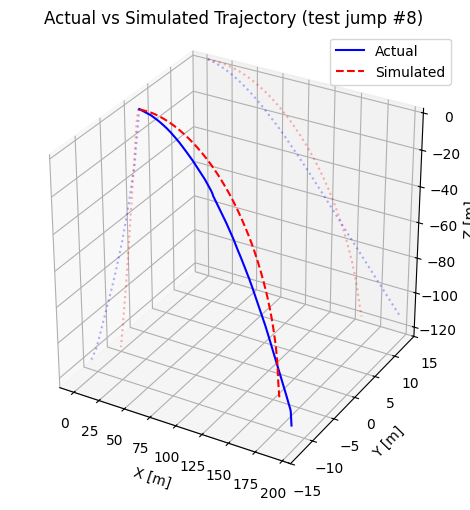

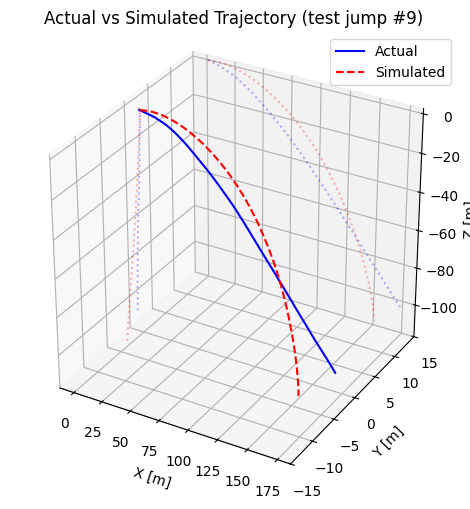

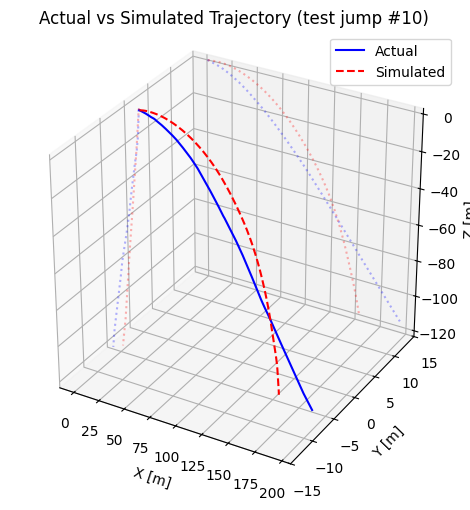

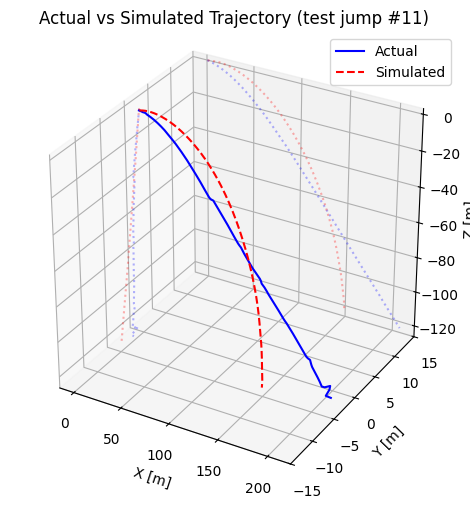

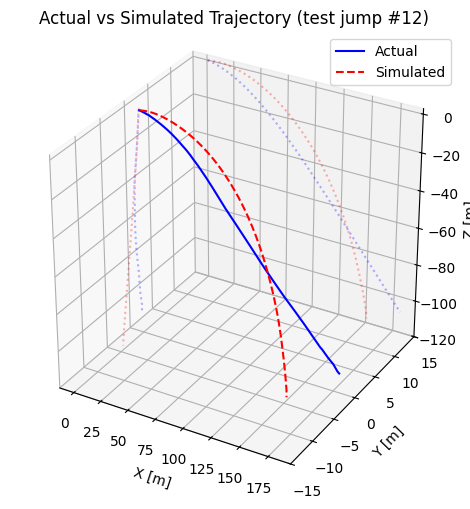

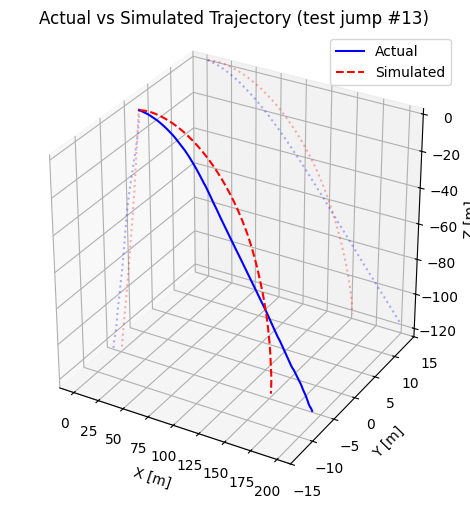

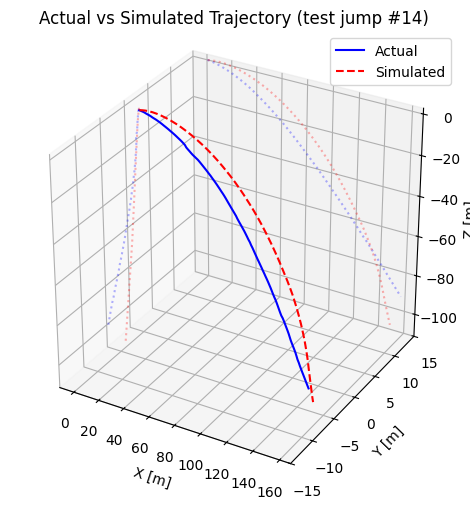

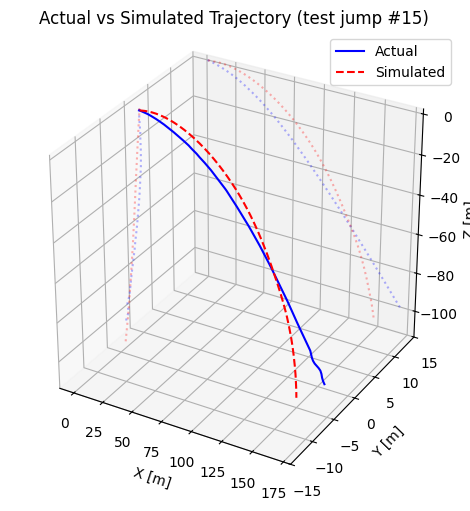

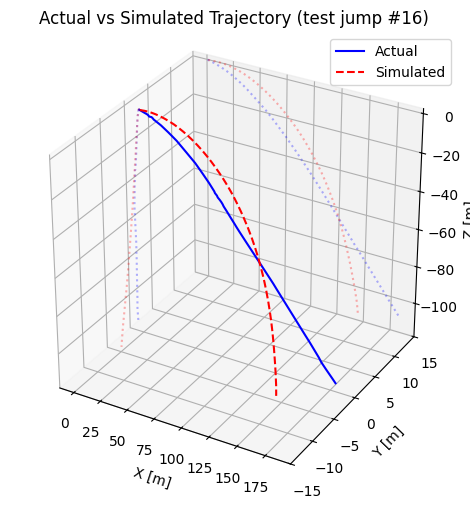

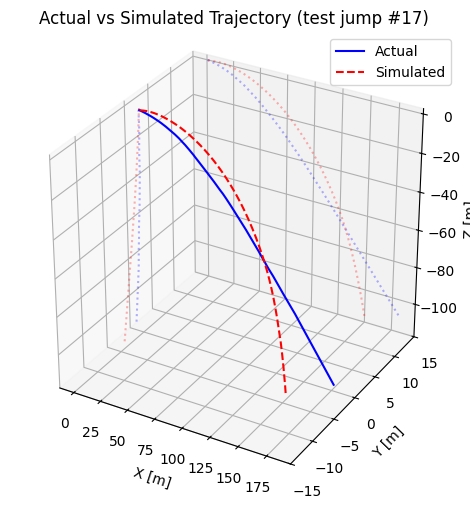

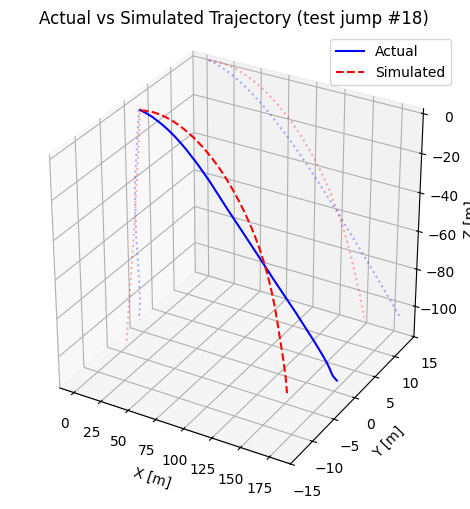

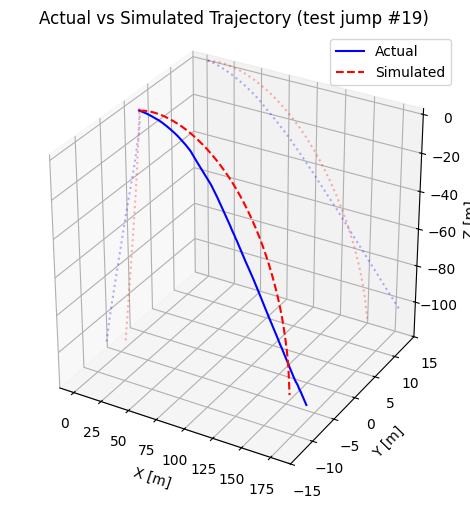

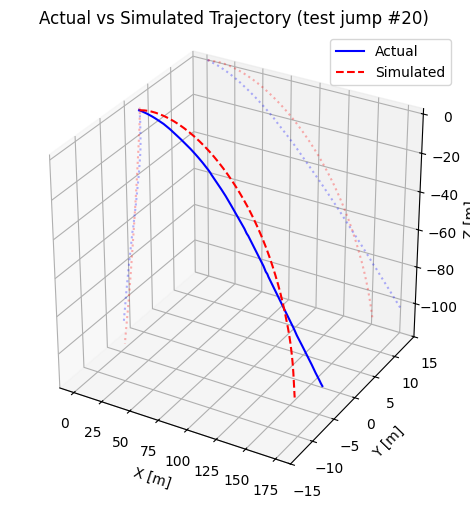

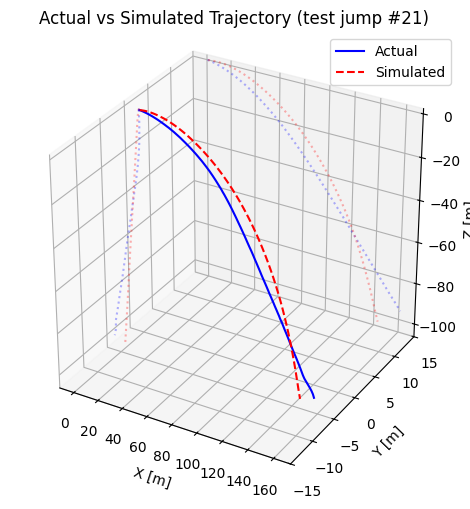

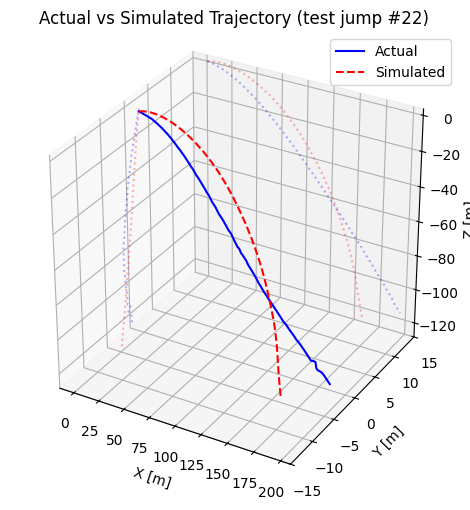

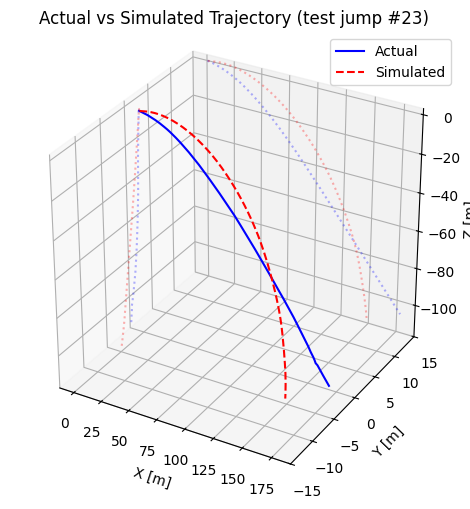

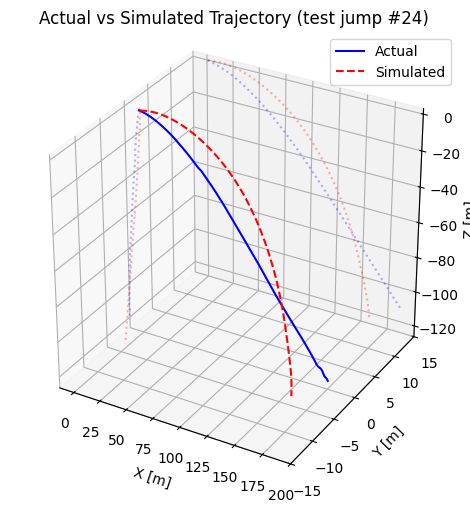

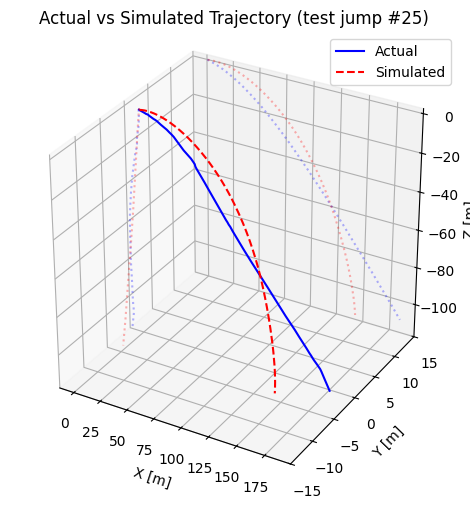

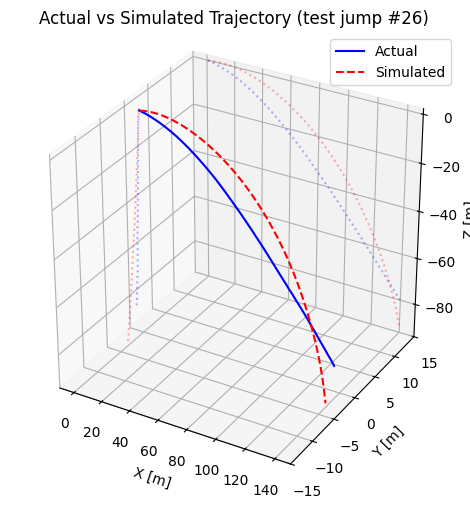

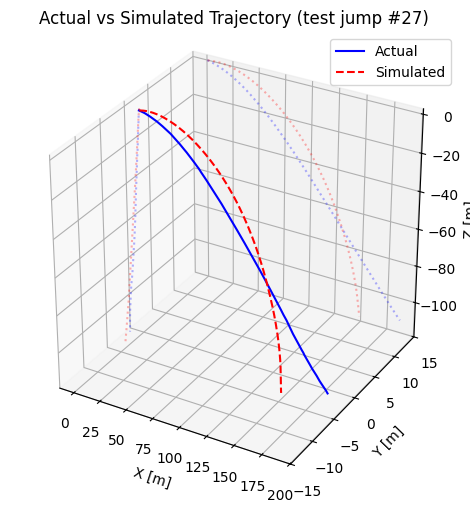

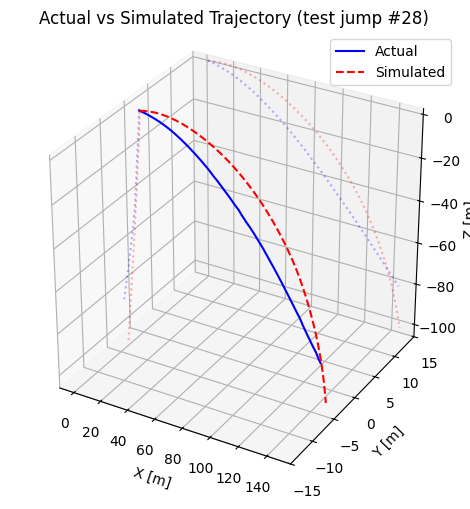

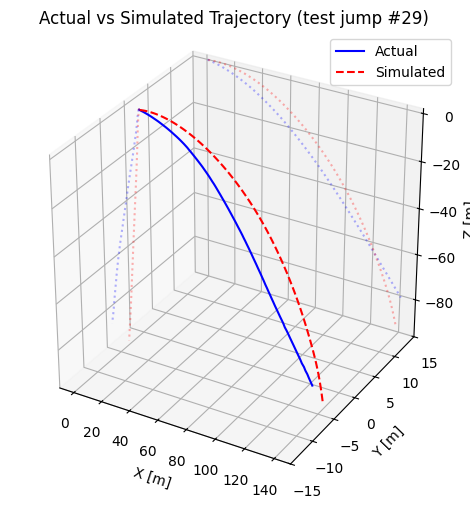

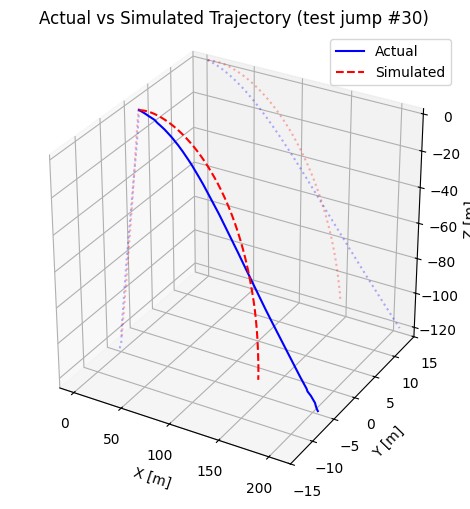

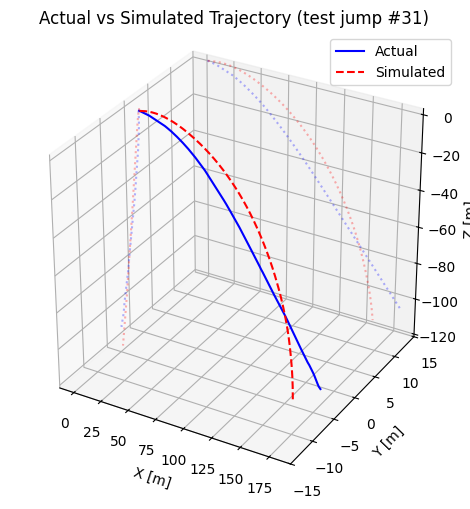

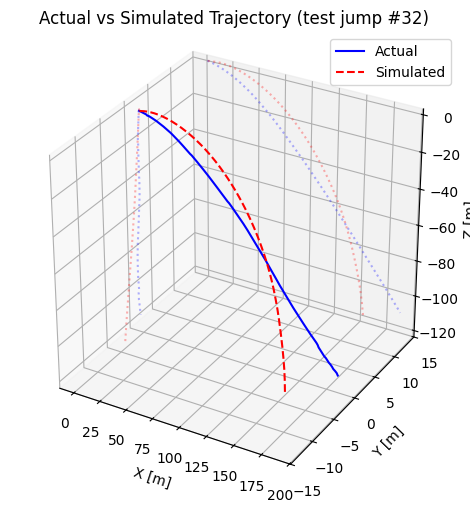

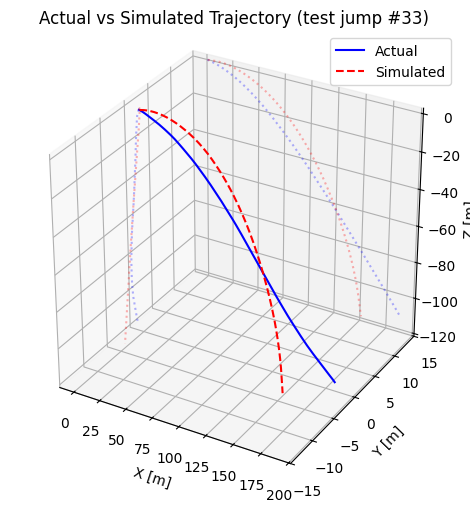

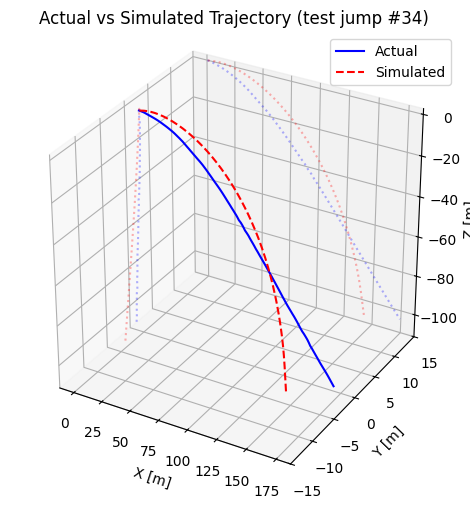

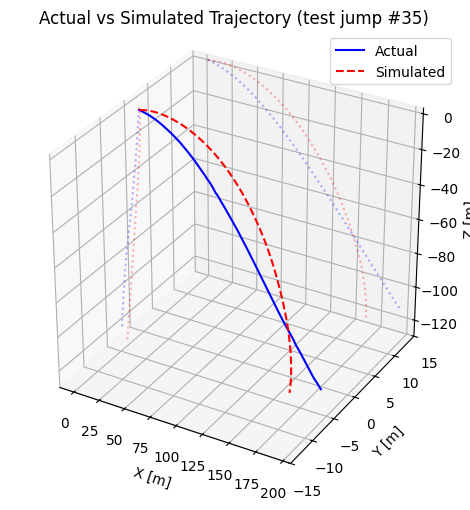

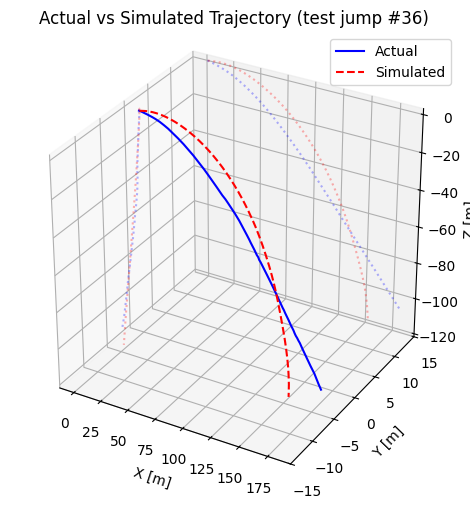

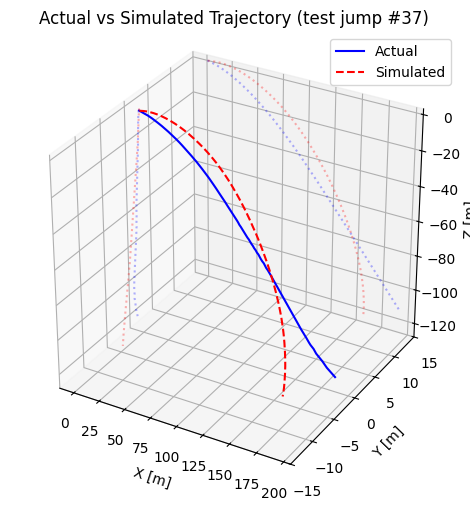

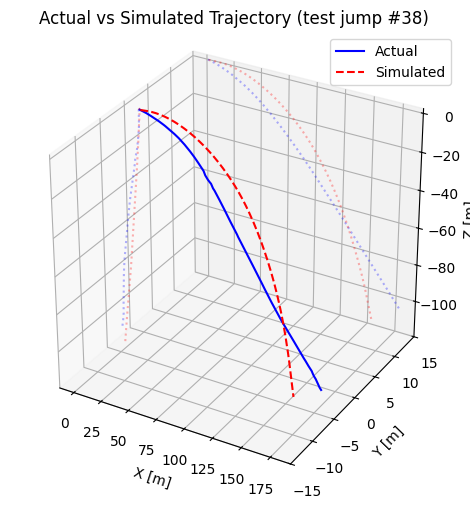

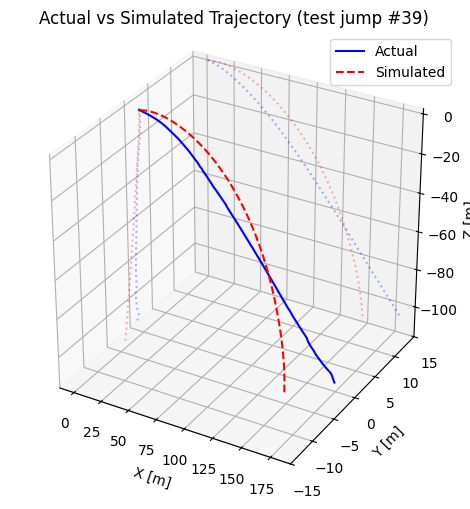

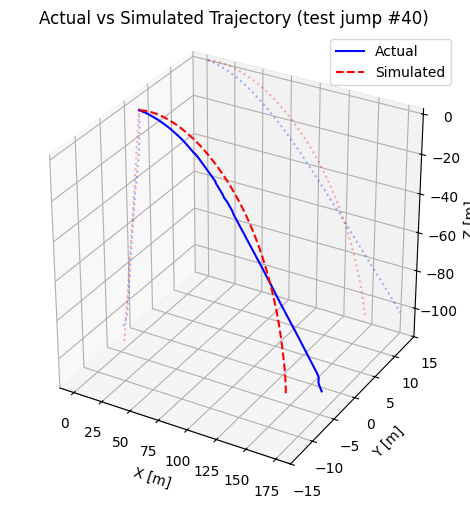

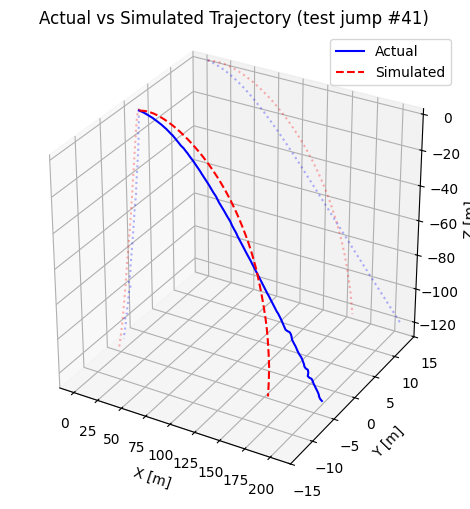

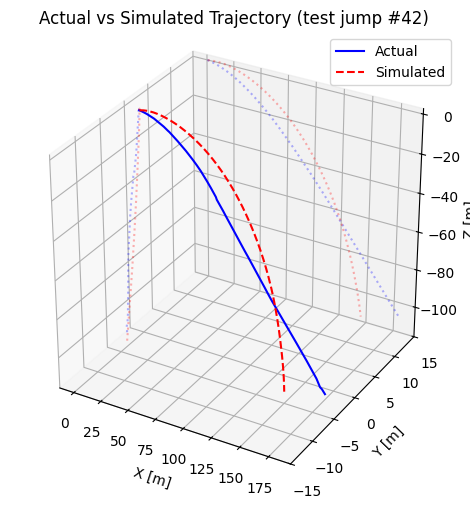

In [374]:

save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)

for idx in range(len(X_test)):

    jump_idx = idx

    x0 = X_test[jump_idx][1] 
    U_seq = U_test[jump_idx]      # controls for that flight
    X_sim = simulate(A_stable, B_new, b_new, x0, U_seq)

    actual = X_test[jump_idx][:, :3]
    sim = X_sim[:, :3]


    Xa = actual[:,0]
    Ya = actual[:,1]
    Za = actual[:,2]

    Xs = sim[:,0]
    Ys = sim[:,1]
    Zs = sim[:,2]

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')



    ax.set_title(f"Actual vs Simulated Trajectory (test jump #{jump_idx + 1})")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    plt.tight_layout()

    name = f"flight_simulation{jump_idx + 1}.png"
    plt.savefig(os.path.join(save_dir, name), dpi=300)

    plt.show()

#### dodana simulacija observations-doesn't change much

In [281]:
def simulate_trajectory_with_observations(x0, U_seq, A, B, C, D):
    """
    Simulate state trajectory and corresponding observations.
    
    Args:
        x0: initial state (shape: [state_dim])
        U_seq: control inputs sequence (shape: [T, control_dim])
        A, B: system matrices for state update
        C, D: output matrices for observations
        
    Returns:
        X_sim: simulated states (shape: [T+1, state_dim])
        Y_sim: simulated observations (shape: [T+1, obs_dim])
    """
    X_sim = [x0]
    Y_sim = []
    
    for u in U_seq:
        x_next = A @ X_sim[-1] + B @ u
        X_sim.append(x_next)
        y_next = C @ x_next + D @ u
        Y_sim.append(y_next)
    
    # Convert lists to numpy arrays
    X_sim = np.array(X_sim)              # shape (T+1, state_dim)
    Y_sim = np.array(Y_sim)              # shape (T, obs_dim) (one observation per input)
    
    # For alignment, prepend initial observation at t=0:
    y0 = C @ x0 + D @ U_seq[0]           # or just C @ x0 if no input yet
    Y_sim = np.vstack([y0, Y_sim])       # shape (T+1, obs_dim)
    
    return X_sim, Y_sim

# Usage example:
x0 = X_train[4][0]    # initial state of 5th flight
U_seq = U_train[4]    # controls of 5th flight

X_sim, Y_sim = simulate_trajectory_with_observations(x0, U_seq, A, B, C, D)
print("Simulated states shape:", X_sim.shape)
print("Simulated observations shape:", Y_sim.shape)


Simulated states shape: (129, 6)
Simulated observations shape: (129, 6)


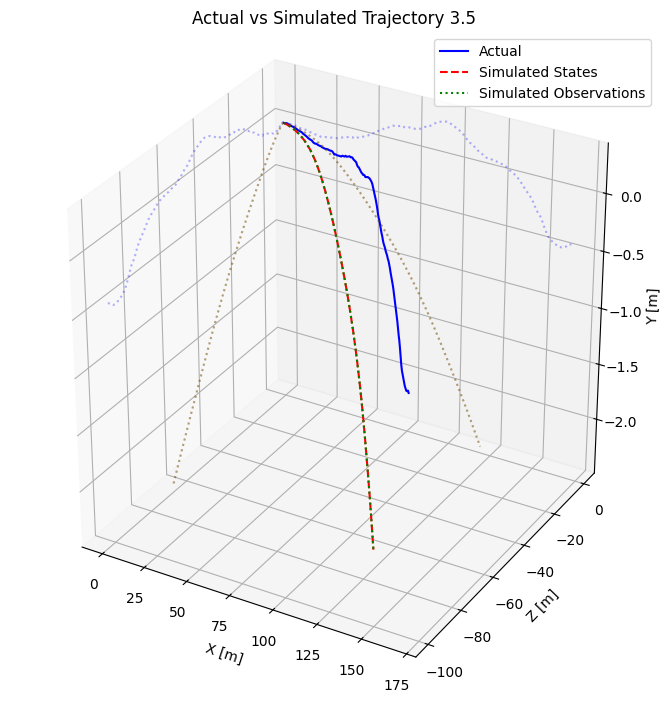

In [282]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Actual trajectory (positions only)
actual = X_train[4][:, :3]   # X, Y, Z from actual states

# Simulated states positions
sim = X_sim[:, :3]          # X, Y, Z from simulated states

# Simulated observations positions
# Assuming Y_sim columns are at least [X, Y, Z, ...], adjust if needed
obs = Y_sim[:, :3]

Xa, Ya, Za = actual[:,0], actual[:,1], actual[:,2]
Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]
Xo, Yo, Zo = obs[:,0], obs[:,1], obs[:,2]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot actual trajectory
ax.plot3D(Xa, Za, Ya, label="Actual", color="blue")

# Plot simulated states trajectory
ax.plot3D(Xs, Zs, Ys, label="Simulated States", color="red", linestyle="--")

# Plot simulated observations trajectory
ax.plot3D(Xo, Zo, Yo, label="Simulated Observations", color="green", linestyle=":")

# Ground projections (X-Z plane)
ax.plot(Xa, 0, Ya, color="blue", alpha=0.3, linestyle=':')
ax.plot(Xs, 0, Ys, color="red", alpha=0.3, linestyle=':')
ax.plot(Xo, 0, Yo, color="green", alpha=0.3, linestyle=':')

# Vertical projections (Z-Y plane)
ax.plot(0, Za, Ya, color="blue", alpha=0.3, linestyle=':')
ax.plot(0, Zs, Ys, color="red", alpha=0.3, linestyle=':')
ax.plot(0, Zo, Yo, color="green", alpha=0.3, linestyle=':')

ax.set_title("Actual vs Simulated Trajectory 3.5")
ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")
ax.set_zlabel("Y [m]")
ax.legend()
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()


## PINN

==================================================================================================
    it doesn't work yet, like at all ker je nekje touple, maš back up the og normalization so you tried to start again

implementacija PINN (physics-informed neural network...ima vgrajene newtnove zakone and such) s pytorch.
Cilj: izboljšat simulacijo, specifično dolžino skokov. 

In [283]:
import torch
from torch.utils.data import Dataset, DataLoader

class SSMFlightDataset(Dataset):
    def __init__(self, X_t, U_t, X_next):
        self.X_t = torch.tensor(X_t, dtype=torch.float32)
        self.U_t = torch.tensor(U_t, dtype=torch.float32)
        self.X_next = torch.tensor(X_next, dtype=torch.float32)

    def __len__(self):
        return len(self.X_t)

    def __getitem__(self, idx):
        return self.X_t[idx], self.U_t[idx], self.X_next[idx]


In [284]:
import torch.nn as nn

class PINNModel(nn.Module):
    def __init__(self, state_dim, control_dim, obs_dim, A, B, C, D):
        super().__init__()
        self.A = torch.tensor(A, dtype=torch.float32, requires_grad=False)      #requires_grad=F...ne treniramo-fiksiramo
        self.B = torch.tensor(B, dtype=torch.float32, requires_grad=False)
        self.C = torch.tensor(C, dtype=torch.float32, requires_grad=False)
        self.D = torch.tensor(D, dtype=torch.float32, requires_grad=False)



        self.state_residual_net = nn.Sequential(
            nn.Linear(state_dim + control_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, state_dim)
        )

        self.obser_residual_net = nn.Sequential(
            nn.Linear(state_dim + control_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, obs_dim)
        )

    def forward(self, x, u):
        physics_state = x @ self.A.T + u @ self.B.T       #x_{t+1} = A*x_{t} + B*u_{t}
        residual_state = self.state_residual_net(torch.cat([x, u], dim=1))      #x in u združi v en vektor
        #print(f"physics[0] = {physics[0]} and residual = {residual[0]}")
        next_state = physics_state + residual_state

        physics_obser = x @ self.C.T + u @ self.D.T       #x_{t+1} = C*x_{t} + D*u_{t}
        residual_obser = self.obser_residual_net(torch.cat([x, u], dim=1))      #x in u združi v en vektor
        next_obser = physics_obser + residual_obser

        return next_state, next_obser


In [318]:
flight_losses = [[] for _, _ in enumerate(zip(X_train, U_train))]

state_dim = A.shape[1]
control_dim = B.shape[1]
obs_dim = C.shape[0]

model = PINNModel(state_dim, control_dim, obs_dim, A, B, C, D)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 400
for epoch in range(epochs):
    total_loss = 0
    for idx, (X_seq, U_seq) in enumerate(zip(X_train, U_train)):
        flight_losses[idx] = []
        X_t = torch.tensor(X_seq[:-1], dtype=torch.float32)
        X_next = torch.tensor(X_seq[1:], dtype=torch.float32)
        U_t = torch.tensor(U_seq[:-1], dtype=torch.float32)

        Y_next = X_next[:, :obs_dim]

        optimizer.zero_grad()

        pred_next_state, pred_next_obser = model(X_t, U_t)

        loss_state = loss_fn(pred_next_state, X_next)
        loss_obser = loss_fn(pred_next_obser, Y_next)
        loss = loss_state + loss_obser

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        napaka = loss.item()
        flight_losses[idx].append(napaka)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch}, Total Loss: {total_loss:.4f}, State Loss: {loss_state.item():.4f}, Obs Loss: {loss_obser.item():.4f}")


Epoch 9, Total Loss: 1895.8767, State Loss: 0.0806, Obs Loss: 8.0559
Epoch 19, Total Loss: 986.0194, State Loss: 0.0729, Obs Loss: 1.2323
Epoch 29, Total Loss: 857.3265, State Loss: 0.0631, Obs Loss: 0.3533
Epoch 39, Total Loss: 797.3364, State Loss: 0.0560, Obs Loss: 0.2581
Epoch 49, Total Loss: 713.4528, State Loss: 0.0621, Obs Loss: 0.2604
Epoch 59, Total Loss: 664.8144, State Loss: 0.0973, Obs Loss: 0.3447
Epoch 69, Total Loss: 613.6905, State Loss: 0.0676, Obs Loss: 0.2053
Epoch 79, Total Loss: 584.4854, State Loss: 0.0539, Obs Loss: 0.1768
Epoch 89, Total Loss: 564.9656, State Loss: 0.0526, Obs Loss: 0.3352
Epoch 99, Total Loss: 539.3375, State Loss: 0.0518, Obs Loss: 0.1801
Epoch 109, Total Loss: 550.3277, State Loss: 0.0584, Obs Loss: 0.3767
Epoch 119, Total Loss: 504.3161, State Loss: 0.0459, Obs Loss: 0.2181
Epoch 129, Total Loss: 541.2643, State Loss: 0.0543, Obs Loss: 0.4668
Epoch 139, Total Loss: 497.3100, State Loss: 0.0435, Obs Loss: 0.2324
Epoch 149, Total Loss: 479.510

In [335]:
mean_losses = [np.mean(lst) for lst in flight_losses]
bad_ids = np.argsort(mean_losses)[-5:]  # worst flights
bad_ids


c:\Users\vsi\Desktop\ijs\smucarski_skoki\project\flight_env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\vsi\Desktop\ijs\smucarski_skoki\project\flight_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


array([162, 163, 164, 165, 166])

Eigenvalues of A: [0.76024631+0.j         0.80616672+0.j         0.9650303 +0.02276774j
 0.9650303 -0.02276774j 1.00190523+0.j         1.01236869+0.j        ]


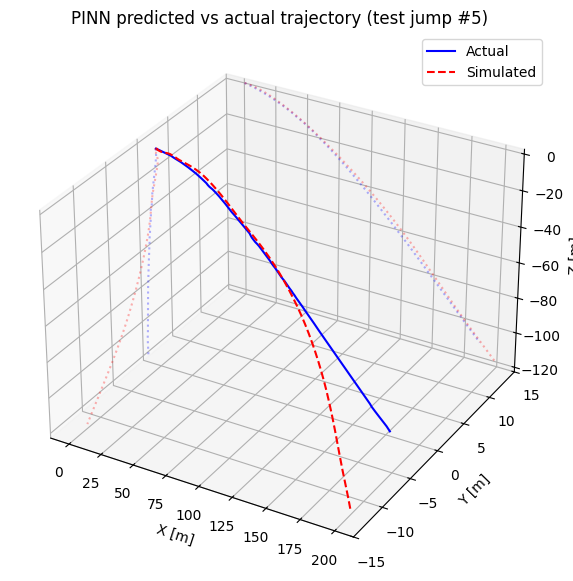

In [344]:
# Pick a jump from TEST set
jump_idx = 4
X_seq_test = X_test[jump_idx]
U_seq_test = U_test[jump_idx]

# Start with the first actual state from the test jump (tensor)
x_pred = [torch.tensor(X_seq_test[0], dtype=torch.float32)]
y_pred = []

# Free-running prediction
for u in U_seq_test[:-1]:
    u_tensor = torch.tensor(u, dtype=torch.float32).unsqueeze(0)
    x_tensor = x_pred[-1].unsqueeze(0)

    next_state, next_obser = model(x_tensor, u_tensor)
    x_pred.append(next_state.squeeze(0).detach())  # still tensor
    y_pred.append(next_obser.squeeze(0).detach())

# Convert to numpy for plotting
x_pred_np = torch.stack(x_pred).numpy()
y_pred_np = torch.stack(y_pred).numpy()

# Extract XYZ from true and predicted
true_xyz = np.array(X_seq_test)[:, :3]
pred_xyz = x_pred_np[:, :3]

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


Xa = true_xyz[:, 0]
Ya = true_xyz[:, 1]
Za = true_xyz[:, 2]

Xs = pred_xyz[:,0]
Ys = pred_xyz[:,1]
Zs = pred_xyz[:,2]

ax.plot(Xa, Ya, Za, label="Actual", color="blue")
ax.plot(Xs, -Ys, Zs, label="Simulated", color="red", linestyle="--")

# Ground projections
ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(0, -Ys, Zs, color="red", alpha=0.3, linestyle=':')


ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.set_title(f"PINN predicted vs actual trajectory (test jump #{jump_idx + 1})")
ax.set_ylim(-15, 15)
ax.legend()
plt.show()


In [334]:
import torch
import torch.nn as nn
import numpy as np
import random

state_dim = A.shape[1]
control_dim = B.shape[1]
obs_dim = C.shape[0]

model = PINNModel(state_dim, control_dim, obs_dim, A, B, C, D)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 400
initial_rollout_len = 5    # start small
rollout_growth = 5         # increase every 50 epochs
teacher_forcing_prob = 0.7 # fraction of sequences trained in teacher forcing

for epoch in range(epochs):
    total_loss = 0.0

    # Gradually increase rollout length
    rollout_len = initial_rollout_len + (epoch // 50) * rollout_growth

    for X_seq, U_seq in zip(X_train, U_train):
        if len(X_seq) <= 1:  # skip invalid sequences
            continue

        # Decide if this sequence will be teacher-forcing or rollout
        if random.random() < teacher_forcing_prob:
            # ----- Teacher forcing (vectorized & fast) -----
            X_t = torch.tensor(X_seq[:-1], dtype=torch.float32)
            X_next = torch.tensor(X_seq[1:], dtype=torch.float32)
            U_t = torch.tensor(U_seq[:-1], dtype=torch.float32)
            Y_next = X_next[:, :obs_dim]

            pred_next_state, pred_next_obser = model(X_t, U_t)

            loss_state = loss_fn(pred_next_state, X_next)
            loss_obser = loss_fn(pred_next_obser, Y_next)
            loss = loss_state + loss_obser

        else:
            # ----- Free-rollout but only up to rollout_len -----
            x_pred = torch.tensor(X_seq[0], dtype=torch.float32).unsqueeze(0)
            seq_loss_state = 0.0
            seq_loss_obs = 0.0
            steps = min(len(X_seq)-1, rollout_len)

            for t in range(steps):
                u_t = torch.tensor(U_seq[t], dtype=torch.float32).unsqueeze(0)
                x_target = torch.tensor(X_seq[t+1], dtype=torch.float32).unsqueeze(0)
                y_target = x_target[:, :obs_dim]

                pred_state, pred_obs = model(x_pred, u_t)

                seq_loss_state += loss_fn(pred_state, x_target)
                seq_loss_obs += loss_fn(pred_obs, y_target)

                # Feed prediction into next step
                x_pred = pred_state.detach()  # stop gradient from exploding

            loss = (seq_loss_state + seq_loss_obs) / steps

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Total Loss: {total_loss:.4f}, Rollout Len: {rollout_len}")


Epoch 1, Total Loss: 38478.9883, Rollout Len: 5
Epoch 2, Total Loss: 23845.0072, Rollout Len: 5
Epoch 3, Total Loss: 15517.9937, Rollout Len: 5
Epoch 4, Total Loss: 9721.1542, Rollout Len: 5
Epoch 5, Total Loss: 7123.2137, Rollout Len: 5
Epoch 6, Total Loss: 5152.9896, Rollout Len: 5
Epoch 7, Total Loss: 4890.0961, Rollout Len: 5
Epoch 8, Total Loss: 3051.1664, Rollout Len: 5
Epoch 9, Total Loss: 3734.1531, Rollout Len: 5
Epoch 10, Total Loss: 3132.8392, Rollout Len: 5
Epoch 11, Total Loss: 2437.2945, Rollout Len: 5
Epoch 12, Total Loss: 2036.0233, Rollout Len: 5
Epoch 13, Total Loss: 2270.6299, Rollout Len: 5
Epoch 14, Total Loss: 1685.7429, Rollout Len: 5
Epoch 15, Total Loss: 2214.4559, Rollout Len: 5
Epoch 16, Total Loss: 1545.0157, Rollout Len: 5
Epoch 17, Total Loss: 1580.3056, Rollout Len: 5
Epoch 18, Total Loss: 1793.1046, Rollout Len: 5
Epoch 19, Total Loss: 2359.0474, Rollout Len: 5
Epoch 20, Total Loss: 1767.6972, Rollout Len: 5
Epoch 21, Total Loss: 1787.8572, Rollout Len: 

#### napaka by time step

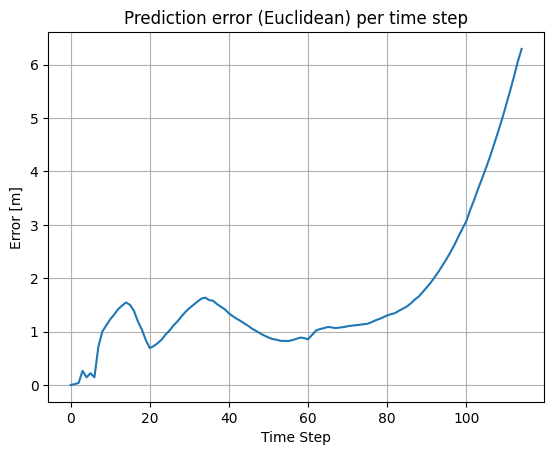

In [329]:
from numpy.linalg import norm

error = norm(pred_xyz - true_xyz, axis=1)

plt.plot(error)
plt.title("Prediction error (Euclidean) per time step")
plt.xlabel("Time Step")
plt.ylabel("Error [m]")
plt.grid(True)
plt.show()


#### loop

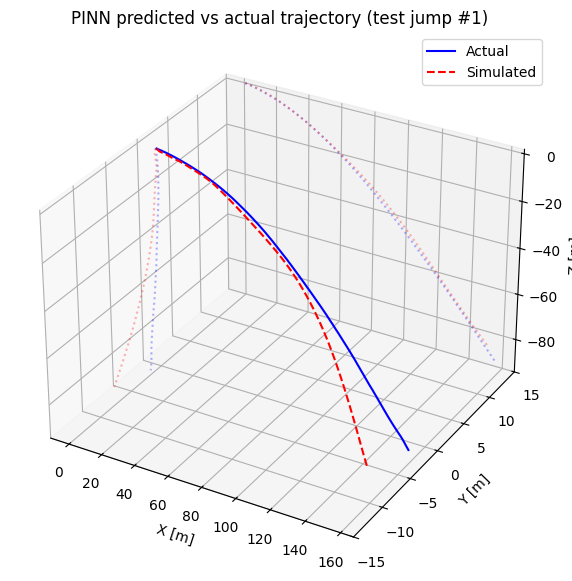

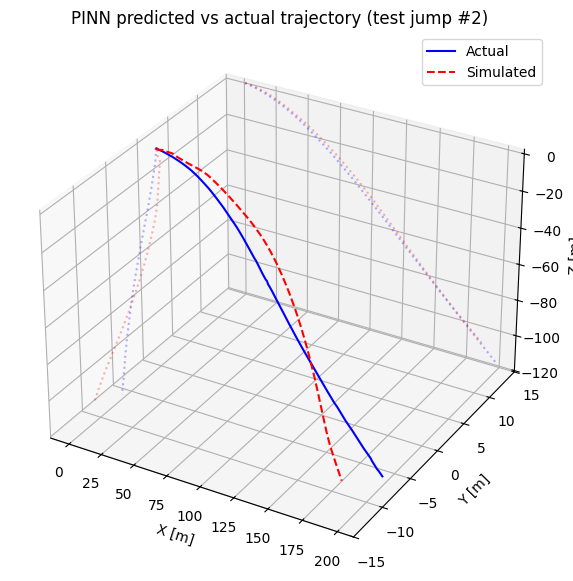

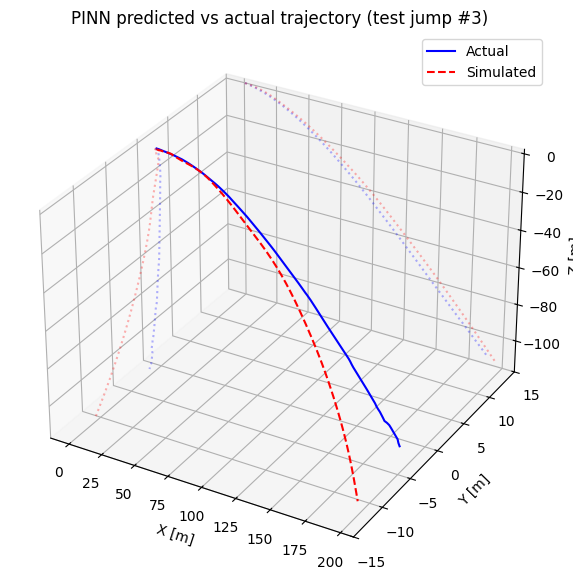

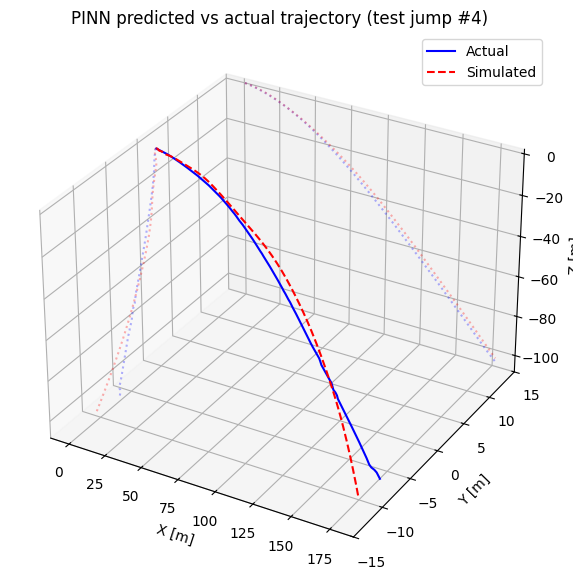

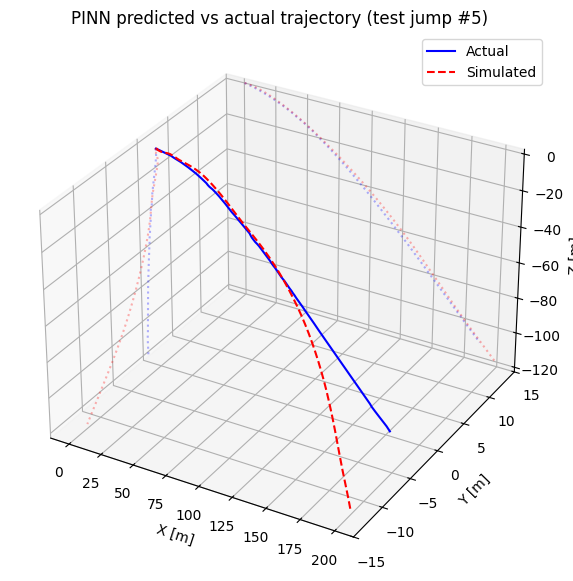

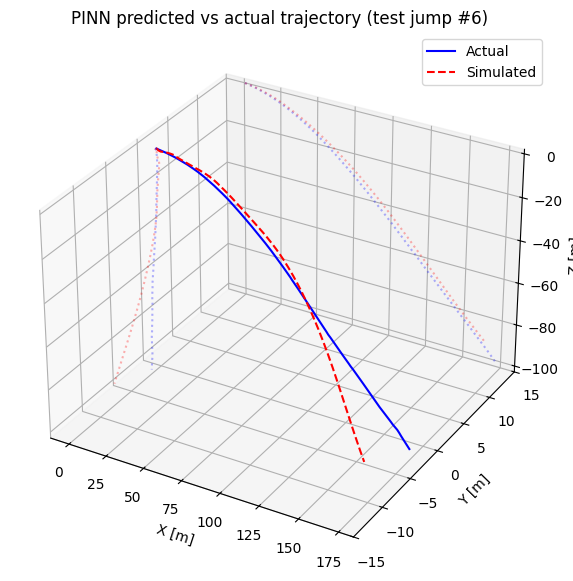

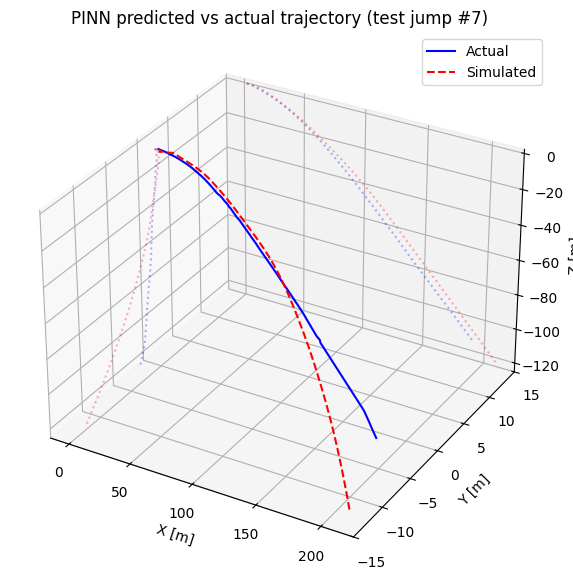

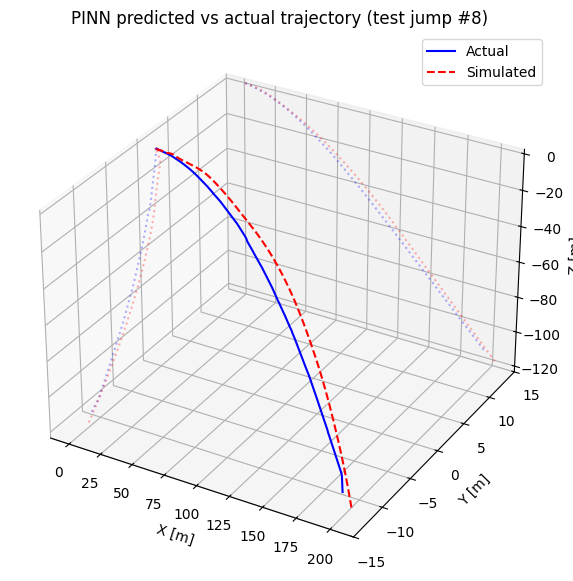

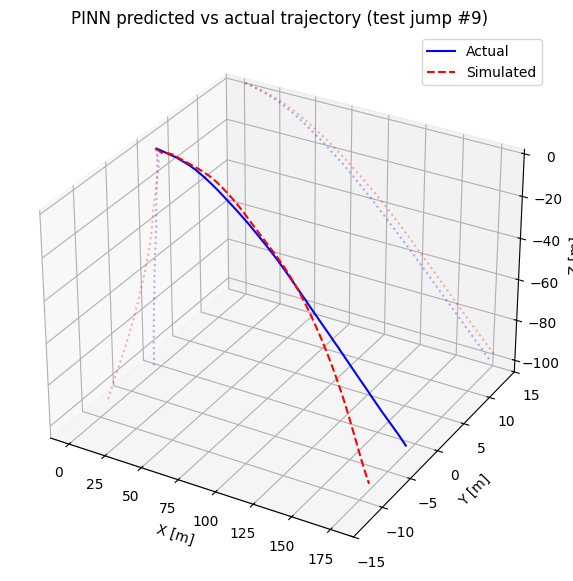

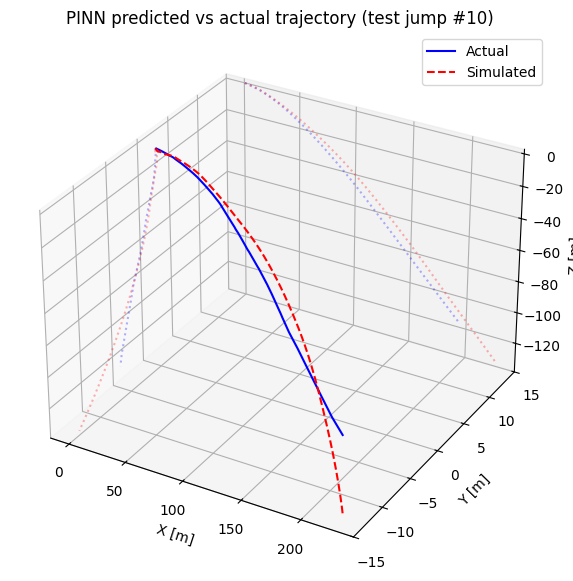

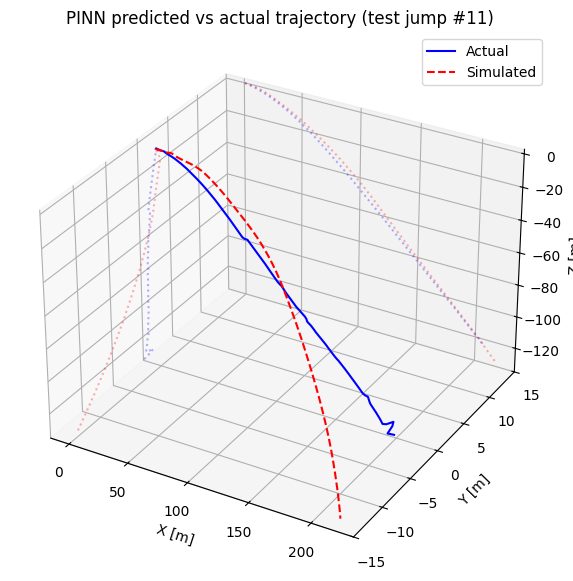

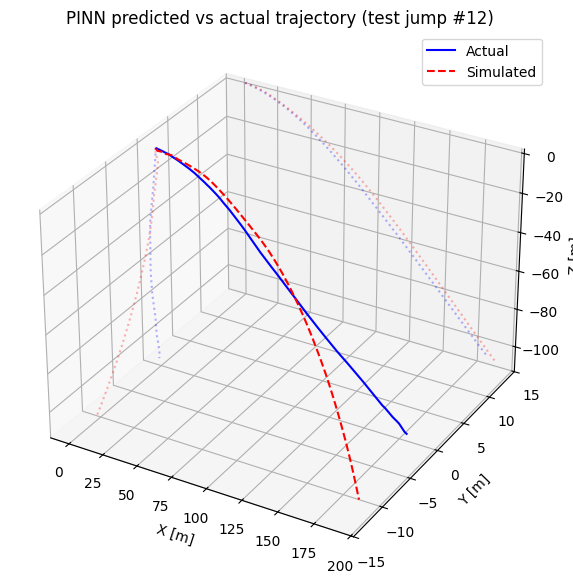

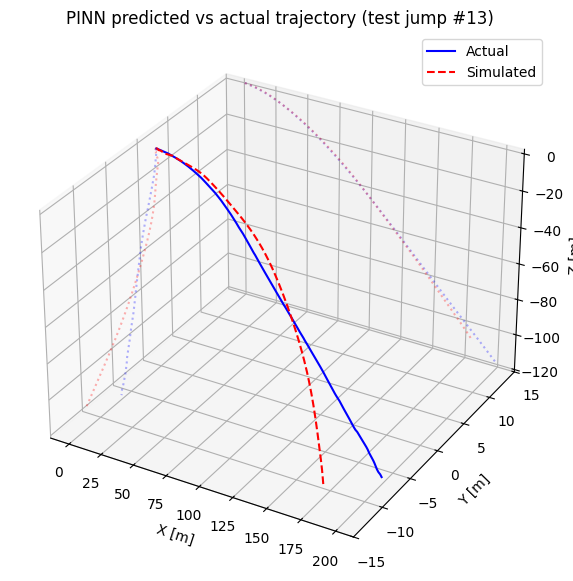

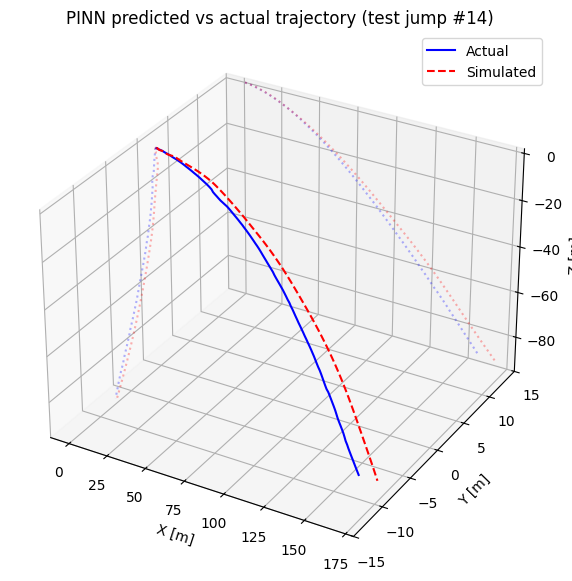

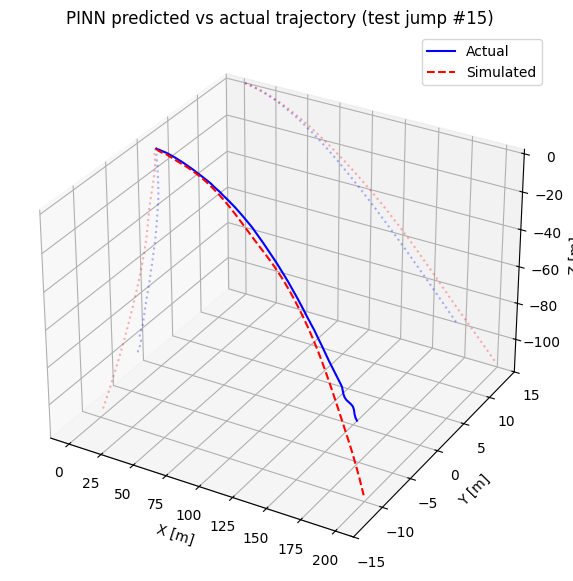

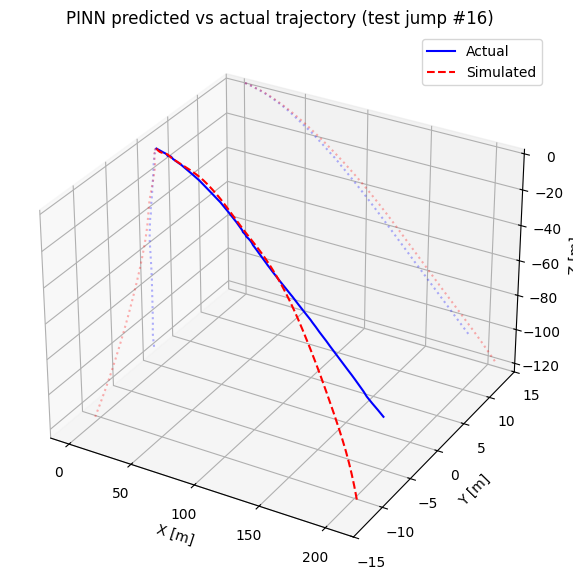

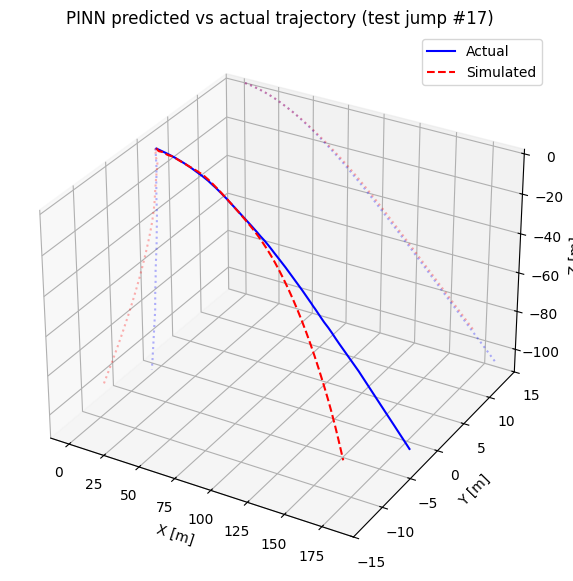

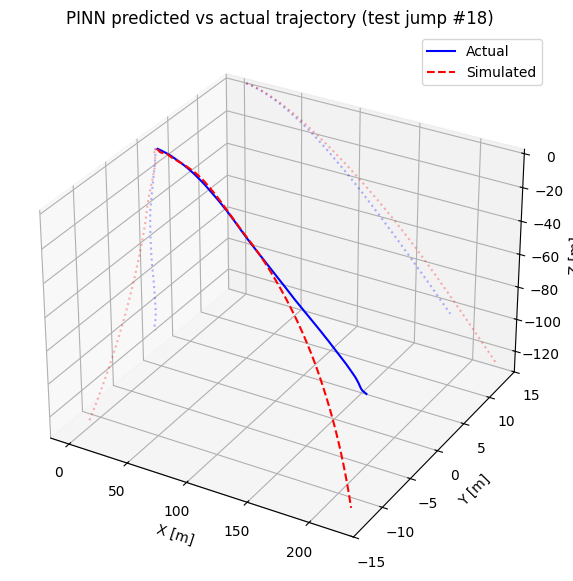

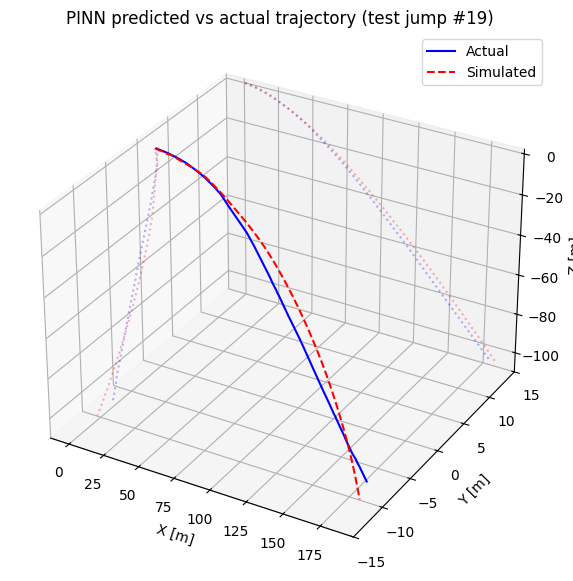

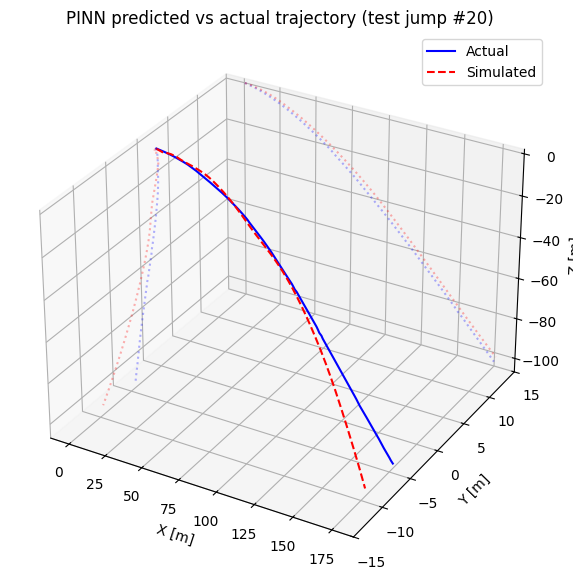

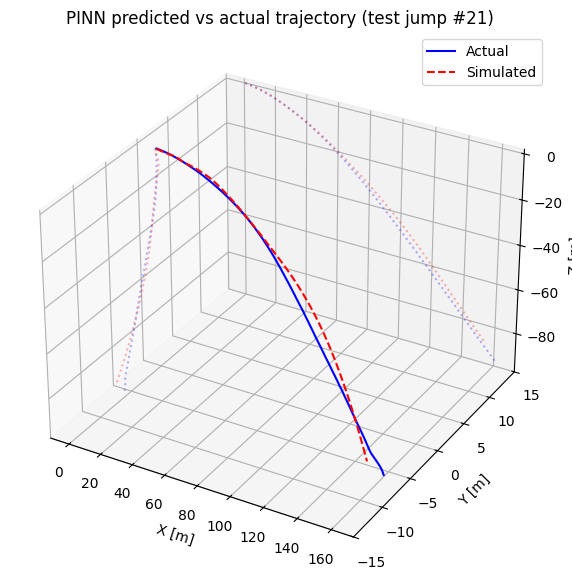

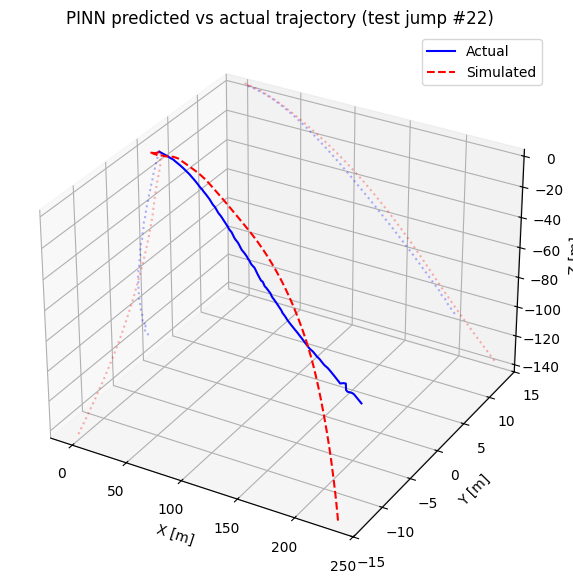

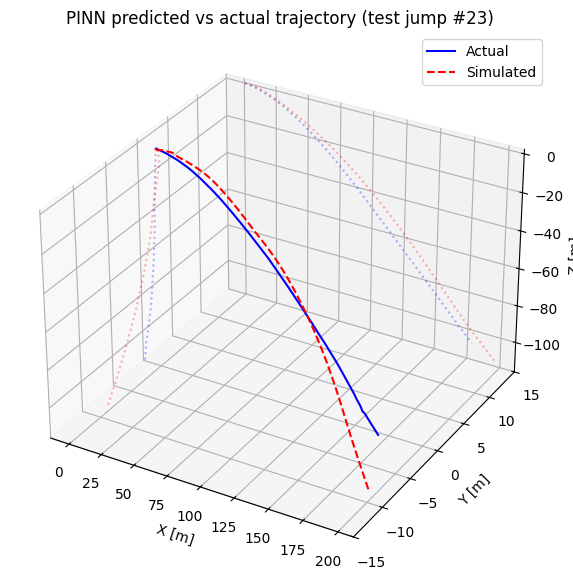

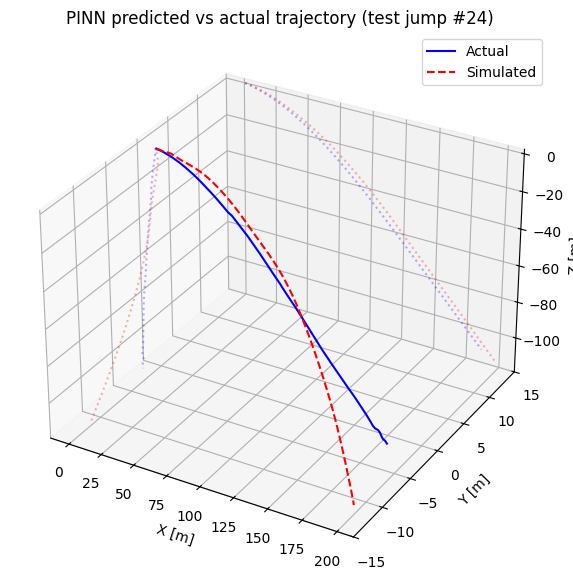

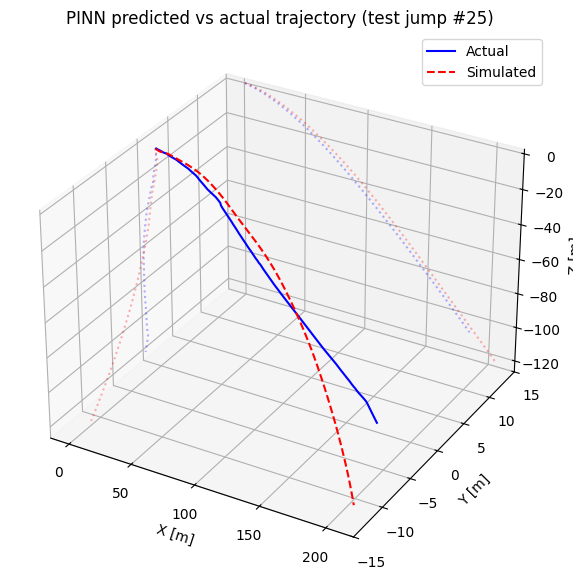

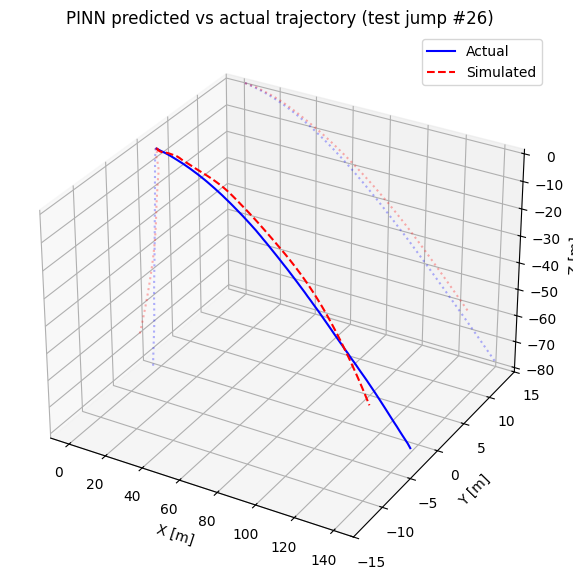

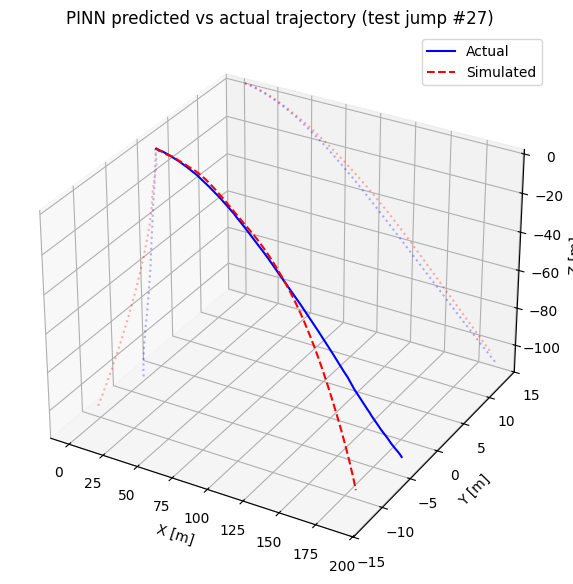

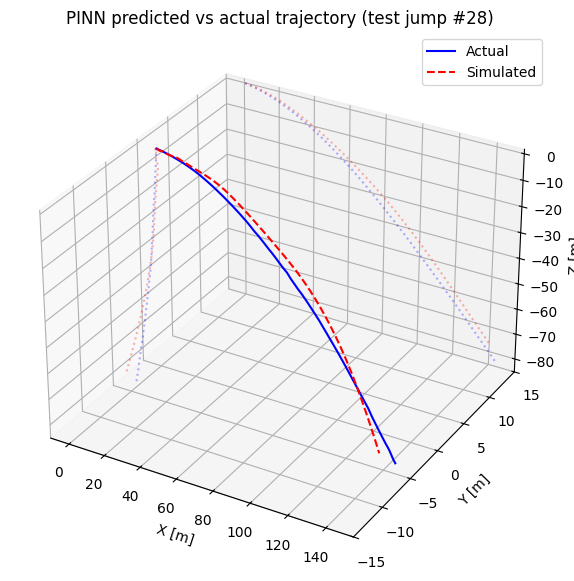

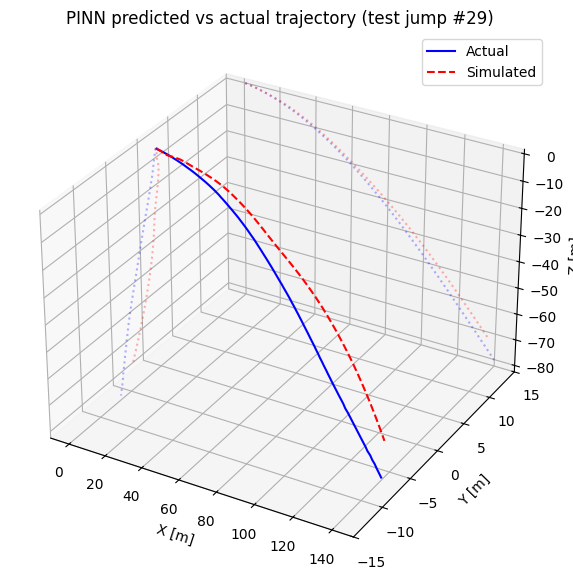

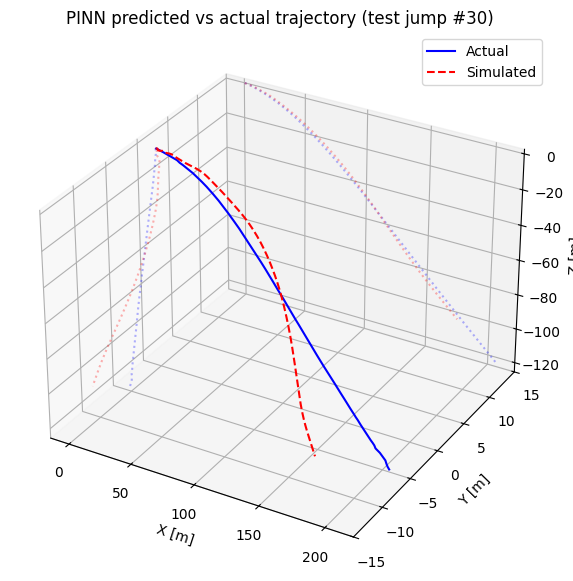

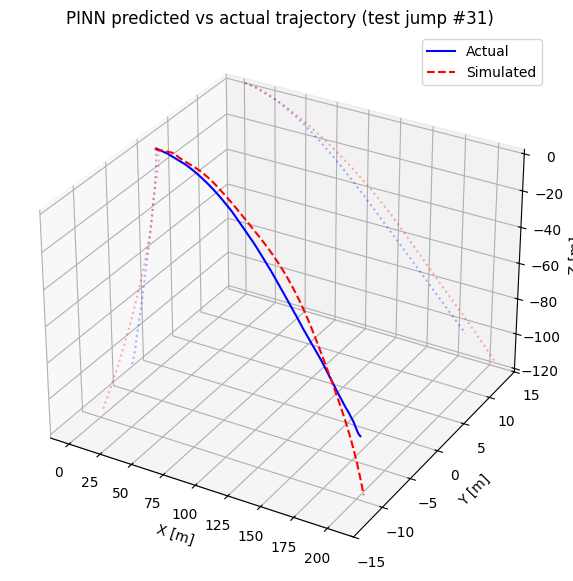

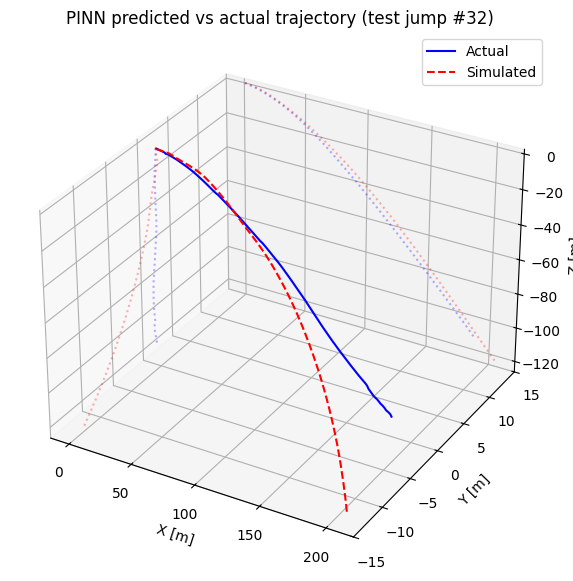

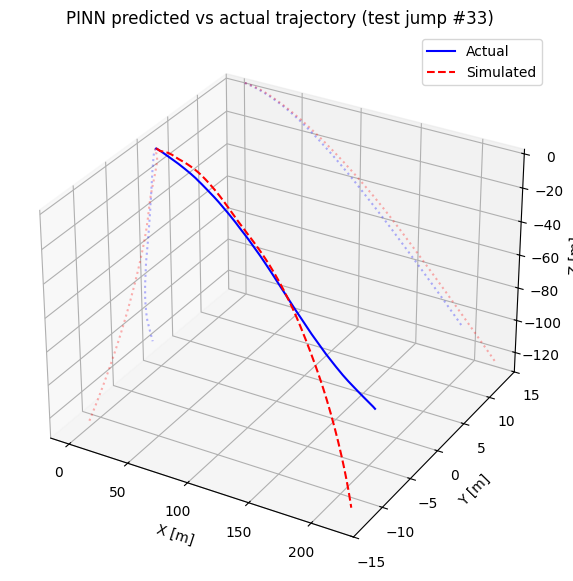

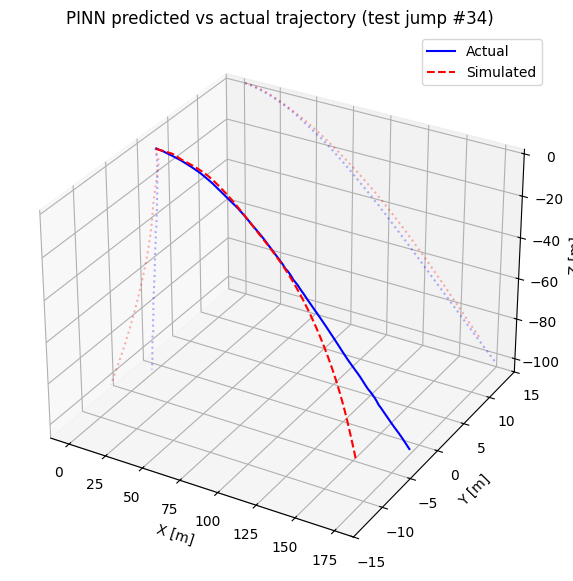

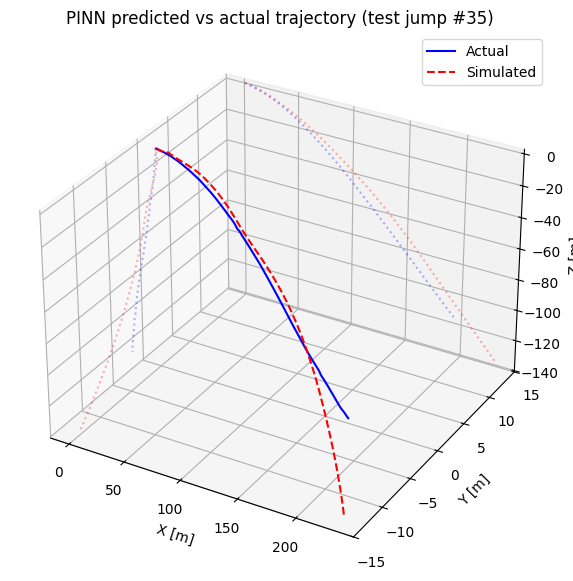

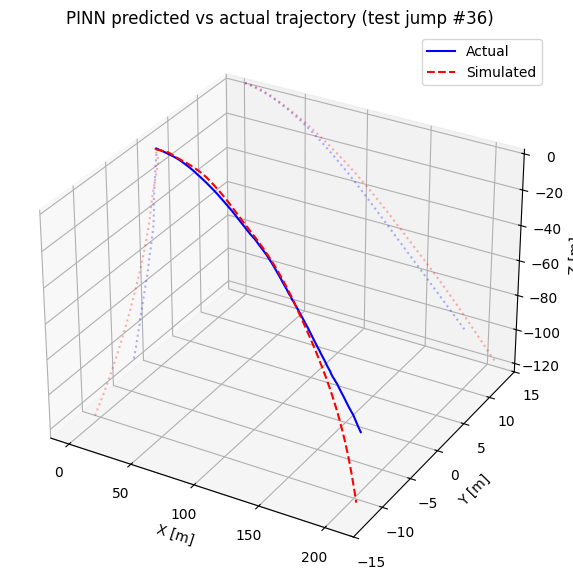

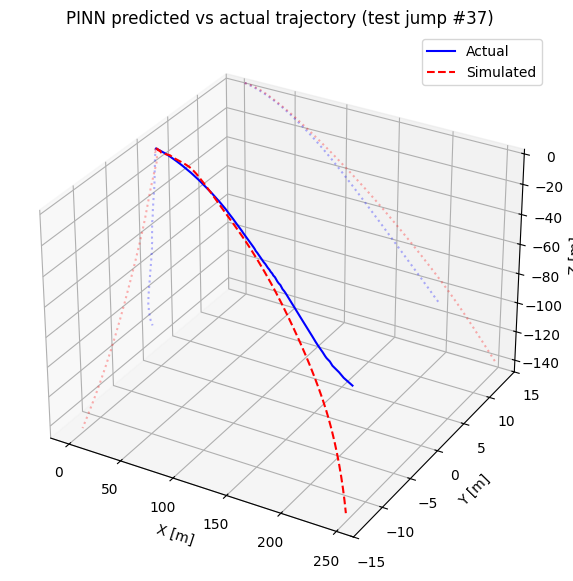

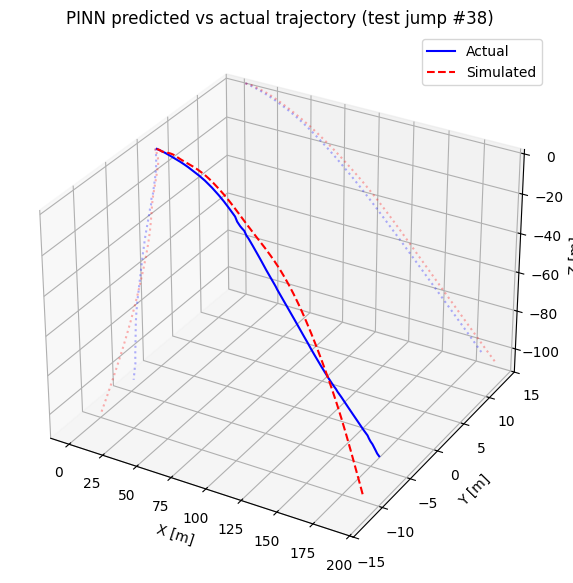

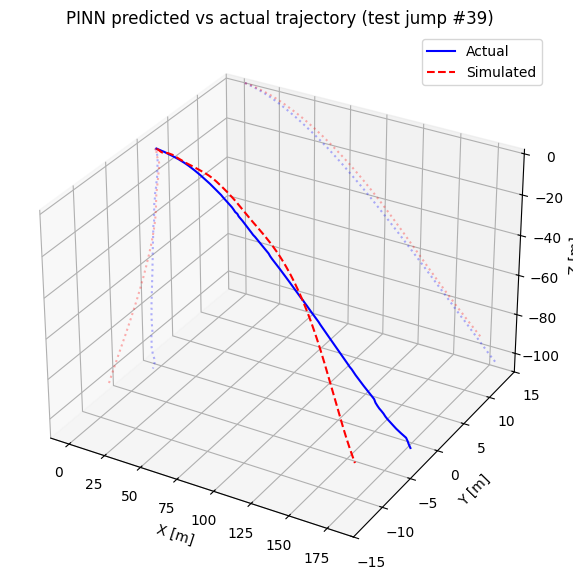

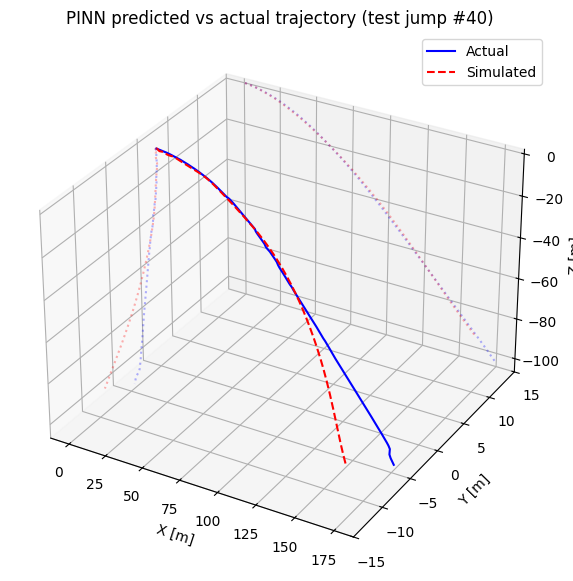

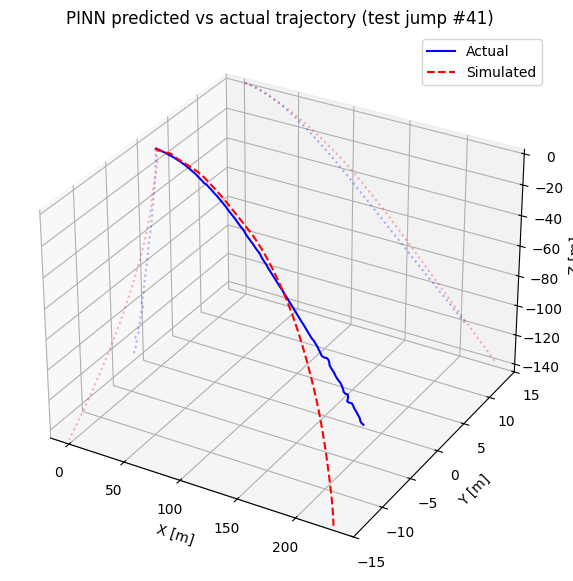

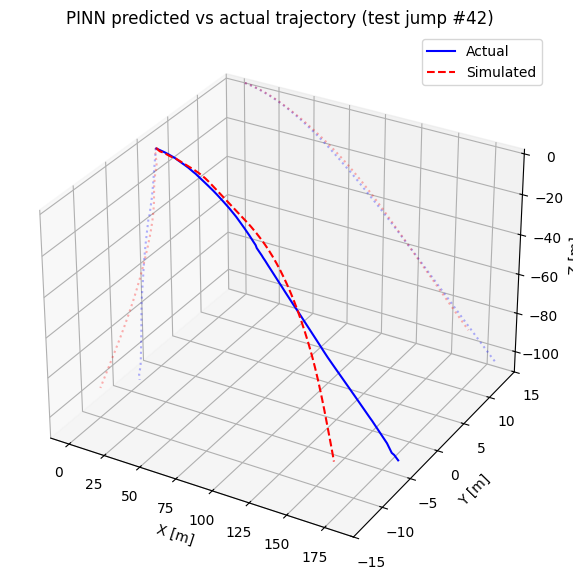

In [345]:

save_dir = "plots/simulated/mirroring"
os.makedirs(save_dir, exist_ok=True)

for idx in range(len(X_test)):
    # Pick a jump from TEST set
    jump_idx = idx
    X_seq_test = X_test[jump_idx]
    U_seq_test = U_test[jump_idx]

    # Start with the first actual state from the test jump (tensor)
    x_pred = [torch.tensor(X_seq_test[0], dtype=torch.float32)]
    y_pred = []

    # Free-running prediction
    for u in U_seq_test[:-1]:
        u_tensor = torch.tensor(u, dtype=torch.float32).unsqueeze(0)
        x_tensor = x_pred[-1].unsqueeze(0)

        next_state, next_obser = model(x_tensor, u_tensor)
        x_pred.append(next_state.squeeze(0).detach())  # still tensor
        y_pred.append(next_obser.squeeze(0).detach())

    # Convert to numpy for plotting
    x_pred_np = torch.stack(x_pred).numpy()
    y_pred_np = torch.stack(y_pred).numpy()

    # Extract XYZ from true and predicted
    true_xyz = np.array(X_seq_test)[:, :3]
    pred_xyz = x_pred_np[:, :3]

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')


    Xa = true_xyz[:, 0]
    Ya = true_xyz[:, 1]
    Za = true_xyz[:, 2]

    Xs = pred_xyz[:,0]
    Ys = pred_xyz[:,1]
    Zs = pred_xyz[:,2]

    ax.plot(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot(Xs, -Ys, Zs, label="Simulated", color="red", linestyle="--")

    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, -Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_ylim(-15, 15)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.set_title(f"PINN predicted vs actual trajectory (test jump #{jump_idx + 1})")
    ax.legend()

    name = f"3pinn_flight_simulation{jump_idx + 1}.png"

    plt.savefig(os.path.join(save_dir, name), dpi=300)

    plt.show()


    

#### file names

In [ ]:
for i, (pred, truth) in enumerate(zip(y_pred_all, Y_test)):
    error = torch.max(torch.abs(pred - truth)).item()
    if error > 5.0:  # adjust threshold
        print(f"Unstable prediction in test flight {i} from {test_files[i]}")
